In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import os
import matplotlib.patches as mpatches
import pyccl as ccl
from matplotlib.lines import Line2D
import gc
from matplotlib import cm
from scipy.optimize import curve_fit
from scipy.optimize import minimize
from scipy import linalg

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Model using step-function HOD
## Define parameters

In [3]:
G_hi = 20.5

In [4]:
nthreads = 18

In [5]:
h = 0.6736
Om0 = {'Corrfunc': 0.302, 'Quaia': 0.343, 'Planck': 0.3153}

In [6]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

In [7]:
color1 = plt.get_cmap('Oranges')(np.linspace(0.333, 0.999, 2))[::-1]
color2 = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, 2))[::-1]

In [8]:
color3 = plt.get_cmap('Greys')(np.linspace(0.333, 0.999, 2))[::-1]

In [9]:
# Create the bins array
rpmin = 0.15 # 0.5 # 0.1 # start higher
rpmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rpbins = np.logspace(np.log10(rpmin), np.log10(rpmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

In [10]:
pimax = 80 # 40 # 5000.0 # 40.0

In [11]:
dpi = 0.01
pibins = np.arange(0, pimax+1, dpi)

In [12]:
z_bins = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
z_array = range(len(z_bins)-1)
mask = 0.5

In [13]:
cmap_qq = plt.get_cmap('Oranges')(np.linspace(0.333, 0.999, len(z_array)))
cmap_mm = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, len(z_array)))
cmap_b = plt.get_cmap('Greys')(np.linspace(0.333, 0.999, len(z_array)))
cmaps = [cmap_qq, cmap_mm]

In [14]:
orange = plt.get_cmap('Oranges')((0.333+0.999)/2)
green = plt.get_cmap('Greens')((0.333+0.999)/2)
grey = plt.get_cmap('Greys')((0.333+0.999)/2)
colors = [orange, green]

In [15]:
Delta = 200
delta_c = 1.686

In [16]:
hmf = ccl.halos.MassFuncTinker10()

In [17]:
NSIDE = 64

In [18]:
H0 = h* 100 * u.km/u.s/u.Mpc
rbins_Mpc = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))

In [19]:
Omega_c_planck = 0.1200/h**2
Omega_b_planck = 0.02237/h**2
c_f = Omega_c_planck/Om0['Planck']
b_f = Omega_b_planck/Om0['Planck']

In [20]:
cosmo = {'Corrfunc': ccl.Cosmology(Omega_c=c_f*Om0['Corrfunc'], Omega_b=b_f*Om0['Corrfunc'], h=h, n_s=0.9649, sigma8=0.8111, m_nu = 0.06),
          'Quaia': ccl.Cosmology(Omega_c=c_f*Om0['Quaia'], Omega_b=b_f*Om0['Quaia'], h=h, n_s=0.9649, sigma8=0.766, m_nu = 0.06),
          'Planck': ccl.Cosmology(Omega_c=Omega_c_planck, Omega_b = Omega_b_planck, h=h, n_s=0.9649, sigma8=0.8111, m_nu = 0.06)}

## Pick a cosmology

In [21]:
fid = 'Planck'

## Define functions

In [22]:
def a_median(tab_datahi_mask_zbin0, key_zbin0 = ''):
    
    return 1/(1+np.median(tab_datahi_mask_zbin0['redshift_quaia'+key_zbin0]))

In [23]:
def b_qso(xi_qq, xi_mm, f):
    
    return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3

In [24]:
def nu(M, delta_c = delta_c, a = 1, cosmo = cosmo[fid]):
    
    sigma = cosmo.sigmaM(M/cosmo['h'], a = a)
   
    return delta_c/sigma

In [25]:
def n_g_theory(bins, n_total, a = 1, cosmo = cosmo[fid], hmf = hmf, recenter = True):

    if recenter == True:
        bins = quaia.recenter(bins)
    nm = hmf(cosmo, bins/cosmo['h'], a)/cosmo['h']**3
    n_g = nm/(bins*np.log(10))*n_total
    n_g[np.isnan(n_g)]=0
    
    return n_g, nm

def bias(bins, n_m, a = 1, cosmo = cosmo[fid], mod = False, recenter = True):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter)
    if recenter == True:
        bins = quaia.recenter(bins)
    n_g = np.trapz(n_g, bins)
    dn_dm = nm/(bins*np.log(10))

    b1_E_tinker = b1_E_func(nu(bins, a = a, cosmo = cosmo), mod = mod)

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    return bias_function(n_g, integrand, b1_E_tinker, bins, recenter = recenter), n_g

In [26]:
def b1_E_func(nu, Delta = Delta, delta_c = delta_c, mod = False):

    delta_c = 1.686
    
    if mod == False:
        y = np.log10(Delta)
        A =  1.0+0.24*y*np.exp(-(4/y)**4)
        a = 0.44*y-0.88
        B = 0.183
        b =  1.5
        C = 0.019+0.107*y+0.19*np.exp(-(4/y)**4)
        c = 2.4
        
    else:
        A =  1.0
        a = 0.0906
        B = -4.5002
        b =  2.1419
        C = 4.9148
        c = 2.1419
        
    return 1-A*nu**a/(nu**a+delta_c**a)+B*nu**b+C*nu**c # Jose et al
    
def bias_function(n_g, integrand, b, bins, recenter = True):
    
    if recenter == True:
        bins = quaia.recenter(bins)
        
    return 1/n_g*np.trapz(integrand*b, bins)

In [27]:
def cf_2h(bins, n_m, a, cosmo, cf_matter, recenter = True):
    
    b_q, n_g = bias(bins, n_m, a, cosmo, recenter = recenter)
    return b_q**2*cf_matter, b_q

In [28]:
def wp_2h(bins, n_m, a, cosmo, cf_matter, rpbins, pibins, recenter = True):

    # matter correlation function    
    s = np.sqrt(np.sum(np.meshgrid(quaia.recenter(rpbins)**2, quaia.recenter(pibins)**2), axis = 0))
    s_Mpc = (s*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(cosmo['h']* 100 * u.km/u.s/u.Mpc))
        
    xirppi_zbin_i = ccl.correlations.correlation_3d(cosmo, r=np.ravel(s_Mpc), a=a)
    wp_matter_zbin_i = 2*np.trapz(np.reshape(xirppi_zbin_i, np.shape(s_Mpc)), quaia.recenter(pibins), axis = 0)

    return cf_2h(bins, n_m, a, cosmo, wp_matter_zbin_i, recenter = recenter)

In [29]:
def M(bins, n_m, a = 1, cosmo = cosmo[fid], mod = False, recenter = True, hmf = hmf):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter, hmf = hmf)
    if recenter == True:
        n_g = np.trapz(n_g, quaia.recenter(bins))
        dm = np.diff(bins) 
        dn_dm = nm/(quaia.recenter(bins)*np.log(10))
    else:
        n_g = np.trapz(n_g, bins)
        dn_dm = nm/(bins*np.log(10))

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    if recenter == True:
        return bias_function(n_g, integrand, quaia.recenter(bins), bins, recenter = recenter), n_g
    else:
        return bias_function(n_g, integrand, bins, bins, recenter = recenter), n_g

In [30]:
def HOD(bins, M_min, fduty):

    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=M_min]=fduty

    return n_m

In [31]:
def n_DM(cosmo, a, M_min, hmf = hmf, M_max = 16.8, N = 79):
    
    bins = np.logspace(M_min, M_max, N)
    nm = hmf(cosmo, bins/cosmo['h'], a)/cosmo['h']**3 #/u.Mpc**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.trapz(dn_dm, bins)

# Implement halo model
## Plot HOD: $\langle N(M) \rangle = \begin{cases}f_{duty} & M\geq M_{min} \\ 0 & M<M_{min}\end{cases}$
### At fixed $f_{duty}$ and $M_{min}$

In [32]:
bins = np.logspace(9, 16.8, 79)
M_min = 12.8

In [33]:
M_min_array = [12.86, 12.74, 12.79, 12.82]

In [34]:
fduty = [0.018, 0.022, 0.056, 0.071]
n_m_array = []
for i in z_array:        
    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=10**M_min_array[i]]=fduty[i]
    n_m_array.append(n_m)

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_179134/2409304926.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), color = cmap_qq[i])
/tmp/ipykernel_179134/2409304926.py:6: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M (M_\odot)$')


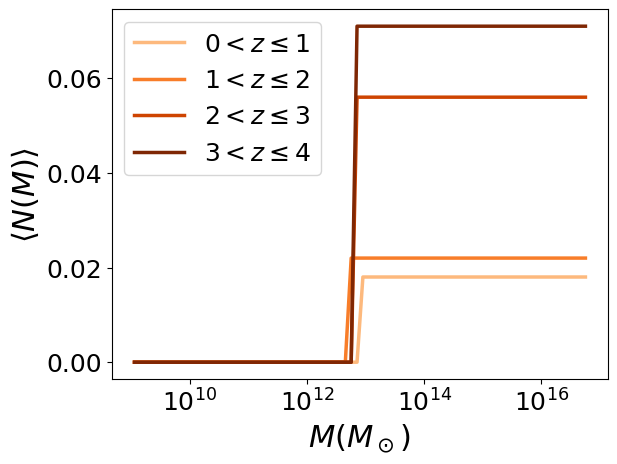

In [35]:
for i in z_array:
        
    plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), color = cmap_qq[i])

plt.xscale('log')
plt.xlabel('$M (M_\odot)$')
plt.ylabel(r'$\langle N(M) \rangle$')
plt.legend()
plt.show()

## Calculate $b_{\mathrm{qq}}(s,z)=\sqrt{\frac{w^{(s)}_{p,{\mathrm{qq}}}(r_p)}{w^{(r)}_{p,\mathrm{mm}}(r_p)}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$
### Use a 50th percentile mask

In [36]:
s = np.sqrt(np.sum(np.meshgrid(quaia.recenter(rpbins)**2, quaia.recenter(pibins)**2), axis = 0))

In [37]:
wp_zbin_percentile, wp_matter_zbin_percentile, rpavg_zbin_percentile = [], [], []
b_wp = []
a_zbin, b_wp_q = [], []
    
for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _ = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)

    # quasar correlation function
    wp_zbin_i, rpavg_zbin_i = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
                                                                  rbins = rpbins, nbins = nbins, pimax = pimax, Om0 = Om0[fid], h = h)
    wp_zbin_percentile.append(wp_zbin_i)
    rpavg_zbin_percentile.append(rpavg_zbin_i)

    # scale factor
    a = a_median(tab_datahi_mask_zbin0)
    a_zbin.append(a)

    # matter correlation function    
    s_Mpc = (s*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
        
    xirppi_zbin_i = ccl.correlations.correlation_3d(cosmo[fid], r=np.ravel(s_Mpc), a=a_median(tab_datahi_mask_zbin0))
    wp_matter_zbin_i = 2*np.trapz(np.reshape(xirppi_zbin_i, np.shape(s_Mpc)), quaia.recenter(pibins), axis = 0)
    wp_matter_zbin_percentile.append(wp_matter_zbin_i)        

    # effective bias 
    b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
    b_wp.append(b)

    # qso bias
    b_wp_q.append(b_qso(wp_zbin_i, wp_matter_zbin_i, ccl.growth_rate(cosmo[fid], a)))

G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336


[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_179134/3970058531.py:30: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
/tmp/ipykernel_179134/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


G20.5_zmin1.0zmax2.0: 0.28              467913 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_179134/3970058531.py:30: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
/tmp/ipykernel_179134/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_179134/3970058531.py:30: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
/tmp/ipykernel_179134/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


G20.5_zmin3.0zmax4.0: 0.21              28061 vs 35630


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_179134/3970058531.py:30: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
/tmp/ipykernel_179134/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


## Measure $\xi(s)$ and calculate the two-halo term: $w_{p,{2 h}}(r_p) \approx\left[n_q^{-1} \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle b_h(M)\right]^2 w_{p,m}(r_p)$
###  Implement Poisson error bars: $\Delta \xi(s)=\begin{cases}\frac{1+\xi(s)}{\sqrt{DD(s)}} & \xi(s)\geq 0 \\ \sqrt{\frac{1+\xi(s)_\mathrm{model}}{D R}} & \xi(s)<0\end{cases}$ 

In [38]:
b_eff_cf20 = np.load('../results/b_eff_cf20.npy')
b_eff_wp20 = np.load('../results/b_eff_wp20.npy')

In [39]:
bins_M_min = np.logspace(M_min, 16.8, 79)

In [40]:
fduty = [0.018, 0.022, 0.056, 0.071]
n_m_array, bins_M_min = [], []
for i in z_array:   
    bins_i = np.logspace(M_min_array[i], 16.8, 79)
    n_m=np.ones(np.shape(bins_i))*fduty[i]
    n_m_array.append(n_m)
    bins_M_min.append(bins_i)

<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_179134/732263424.py:19: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(rpavg_zbin_percentile[j], b_wp[j], linewidth = 2.5, linestyle = '--', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j])


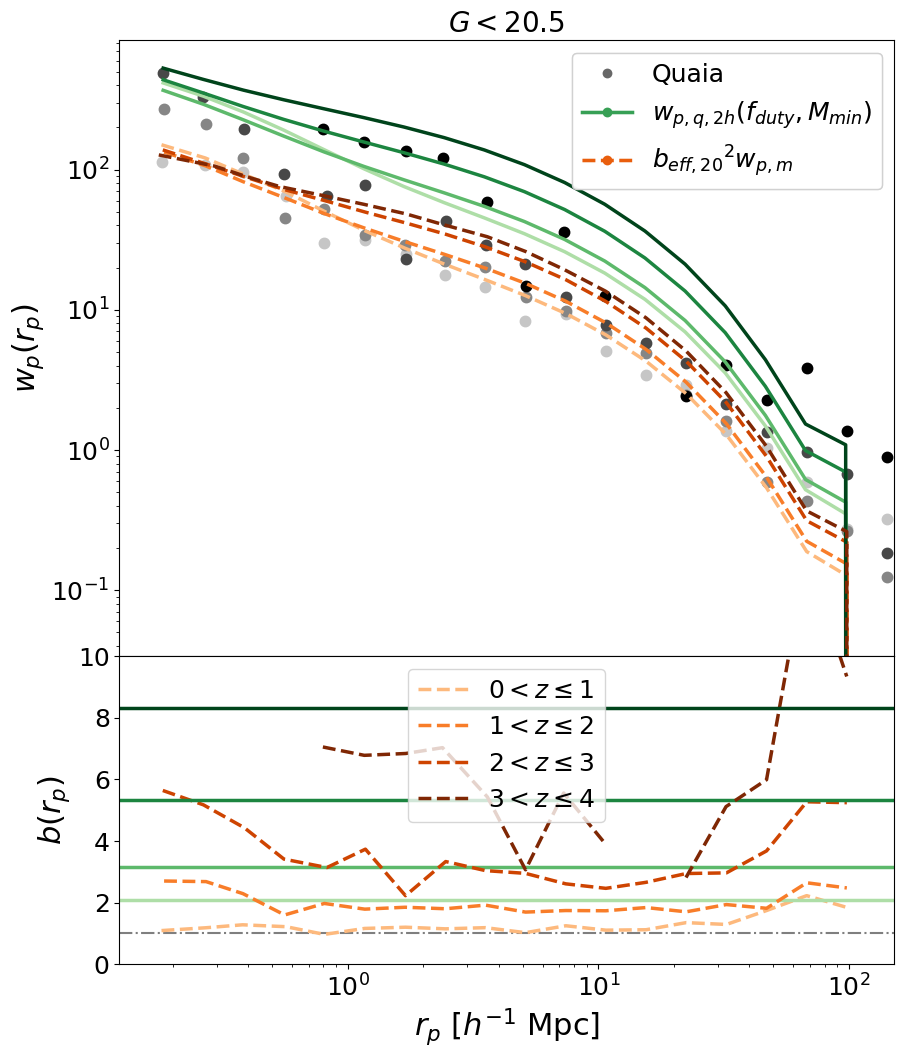

In [41]:
fig = plt.figure(figsize = (10, 12))
gs = gridspec.GridSpec(2, 1, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', r'$\xi_{2h}$']
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

i = 1
for j in z_array:

    ax1.scatter(rpavg_zbin_percentile[j], wp_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_b[j])
    wp_2h_zbin, b_q = wp_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo[fid], wp_matter_zbin_percentile[j], rpbins, pibins, recenter = False)
    ax1.plot(quaia.recenter(rpbins), wp_2h_zbin, linewidth = 2.5, label = r'\xi_2h}',
             color = cmap_mm[j], linestyle = '-')
    ax1.plot(rpavg_zbin_percentile[j], b_eff_wp20[j]**2*wp_matter_zbin_percentile[j], linewidth = 2.5, linestyle = '--',
             label = r'$b_{20}$ model', color = cmap_qq[j])

    ax2.plot(rpavg_zbin_percentile[j], b_wp[j], linewidth = 2.5, linestyle = '--', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j])
    ax2.axhline(b_q, linewidth = 2.5, color = cmaps[i][j])
    
ax1.set_title('$G<{}$'.format(G_hi))
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax1.set_xticklabels([])
# ax1.set_ylim(3e-4, 5e1)

custom_lines = [Line2D([0], [0], color = grey, marker = 'o', linestyle = 'none', linewidth = 2.5),
                Line2D([0], [0], color = green, marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = orange, marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, ['Quaia', r'$w_{p,{q,2h}}(f_{duty}, M_{min})$', r'${b_{eff, 20}}^2w_{p,m}$'], loc = 'upper right')
ax1.add_artist(second_legend)

ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
ax2.axhline(1, linestyle = '-.', color = 'black', zorder = 0, alpha = 0.5)
ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax2.set_ylim(0, 10)
ax2.legend()

ax1.set_ylabel(r'$w_p(r_p)$')
ax2.set_ylabel(r'$b(r_p)$')

if scale == 'log':
    ax1.set_xscale('log')
    ax2.set_xscale('log')

plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_179134/2349350800.py:16: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(rpavg_zbin_percentile[j], b_wp[j], linewidth = 2.5, linestyle = '--', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j])
/tmp/ipykernel_179134/2349350800.py:20: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))


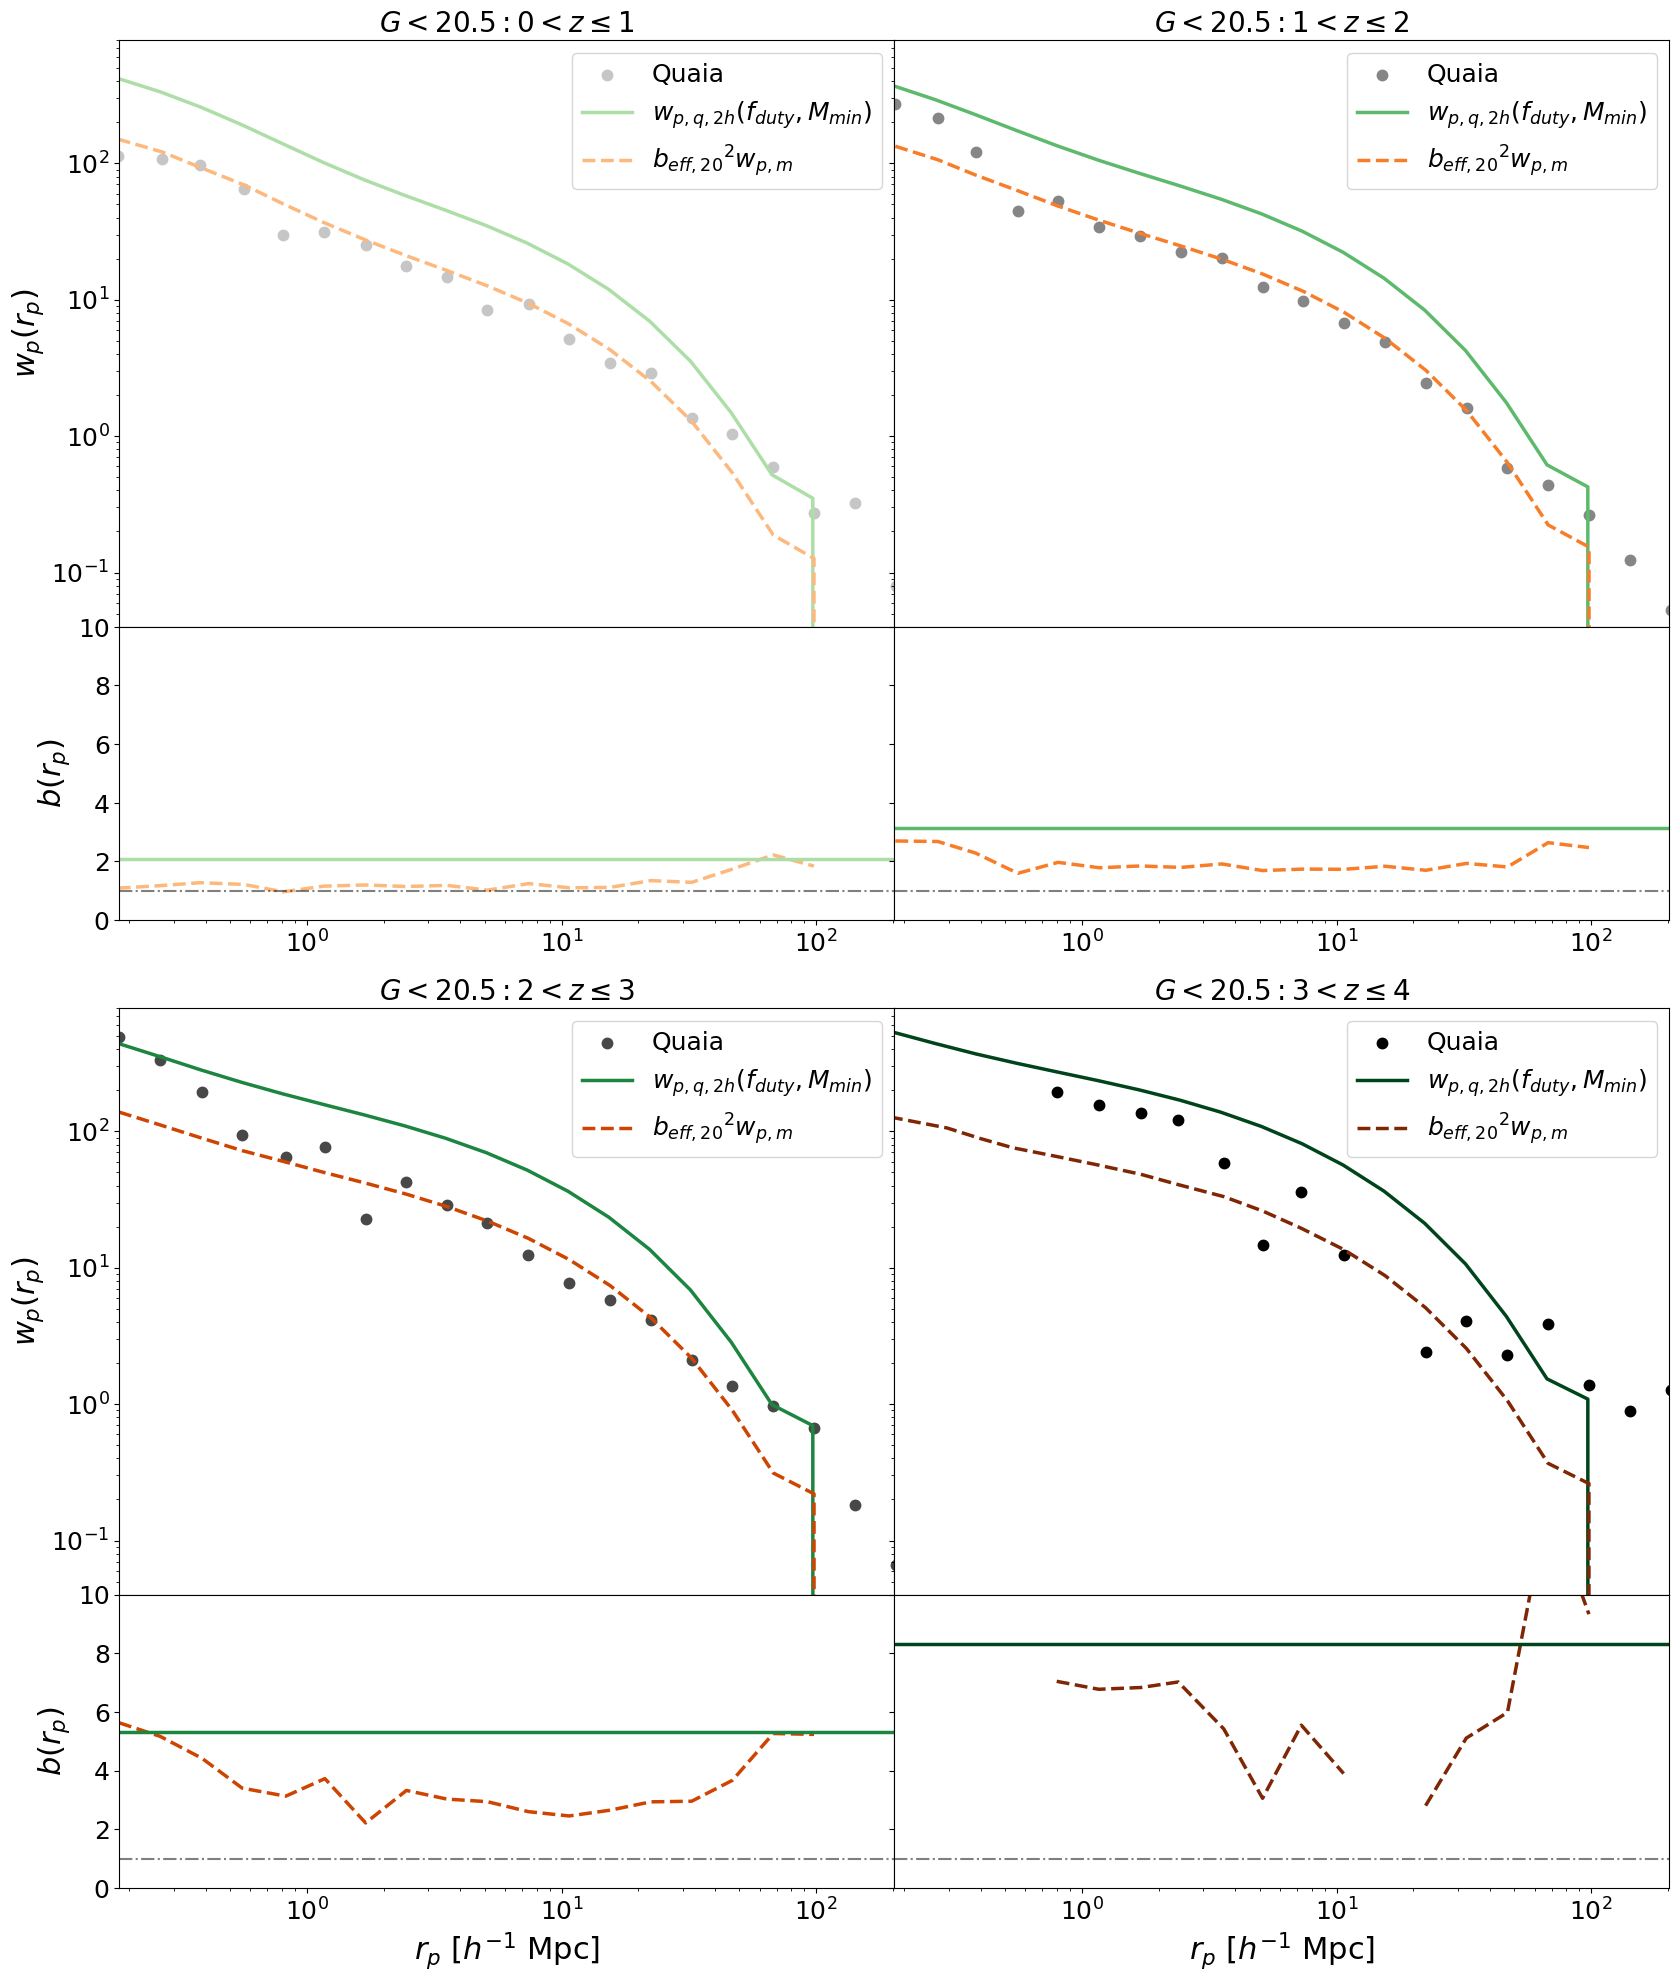

In [42]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.15, 1, 0.5], hspace = 0, wspace = 0)

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
            
    ax1.scatter(rpavg_zbin_percentile[j], wp_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = cmap_b[j])
    wp_2h_zbin, b_q = wp_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo[fid], wp_matter_zbin_percentile[j], rpbins, pibins, recenter = False)
    ax1.plot(quaia.recenter(rpbins), wp_2h_zbin, linewidth = 2.5, label = r'$w_{p,{q,2h}}(f_{duty}, M_{min})$', color = cmaps[i][j])
    ax1.plot(rpavg_zbin_percentile[j], b_eff_wp20[j]**2*wp_matter_zbin_percentile[j], linewidth = 2.5, label = r'${b_{eff, 20}}^2w_{p,m}$', 
             color = cmap_qq[j], linestyle = '--')

    ax2.plot(rpavg_zbin_percentile[j], b_wp[j], linewidth = 2.5, linestyle = '--', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j])
    ax2.axhline(b_q, linewidth = 2.5, color = cmaps[i][j])

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rpbins)[0], quaia.recenter(rpbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(4e-2, 8e2)
    ax1.legend()

    ax2.axhline(1, linestyle = '-.', color = 'black', alpha = 0.5)
    ax2.set_xlim(quaia.recenter(rpbins)[0], quaia.recenter(rpbins)[-1])
    ax2.set_ylim(0, 10)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$w_p(r_p)$')
        ax2.set_ylabel(r'$b(r_p)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
            
    if j % 2 != 0:
        k+=4

plt.show()

### Vary $M_{min}$

In [43]:
n_m_array_2D = []
for i in z_array:

    n_m_array_2D.append([])
    
    for j in range(len(bins)):
        
        n_m=np.ones(np.shape(bins))*fduty[i]
        n_m_array_2D[i].append(n_m)

In [44]:
bins_M_min_array = [np.logspace(np.log10(bins[j]), 16.8, 79) for j in range(len(bins))]

<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_179134/2932887592.py:24: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(rpavg_zbin_percentile[j], b_wp[j], linewidth = 2.5, linestyle = '--', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j])
/tmp/ipykernel_179134/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_179134/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


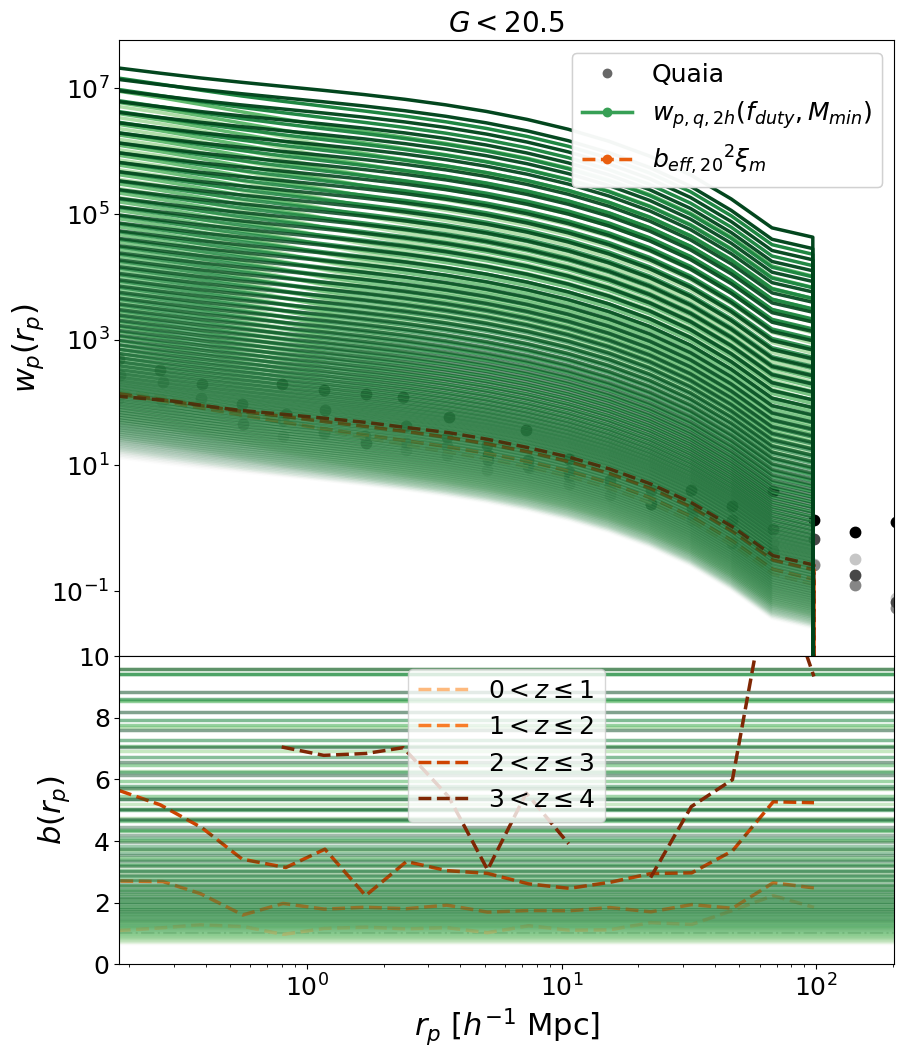

In [45]:
fig = plt.figure(figsize = (10, 12))
gs = gridspec.GridSpec(2, 1, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', r'$\xi_{2h}$']
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

i = 1
for j in z_array:

    ax1.scatter(rpavg_zbin_percentile[j], wp_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_b[j])
    ax1.plot(rpavg_zbin_percentile[j], b_eff_wp20[j]**2*wp_matter_zbin_percentile[j], linewidth = 2.5, linestyle = '--',
             label = r'$b_{20}$ model', color = cmap_qq[j])
    
    for k in range(len(bins)):
        
        wp_2h_zbin, b_q = wp_2h(bins_M_min_array[k], n_m_array_2D[j][k], a_zbin[j], cosmo[fid], wp_matter_zbin_percentile[j], rpbins, pibins, 
                                recenter = False)
        ax1.plot(quaia.recenter(rpbins), wp_2h_zbin, linewidth = 2.5, label = r'\xi_2h}',
             color = cmap_mm[j], linestyle = '-', alpha = (k+1)/len(bins))
        ax2.axhline(b_q, linewidth = 2.5, color = cmaps[i][j],  alpha = (k+1)/len(bins))

    ax2.plot(rpavg_zbin_percentile[j], b_wp[j], linewidth = 2.5, linestyle = '--', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j])
    
ax1.set_title('$G<{}$'.format(G_hi))
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(rpbins)[0], quaia.recenter(rpbins)[-1])
ax1.set_xticklabels([])
# ax1.set_ylim(3e-4, 5e1)

custom_lines = [Line2D([0], [0], color = grey, marker = 'o', linestyle = 'none', linewidth = 2.5),
                Line2D([0], [0], color = green, marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = orange, marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, ['Quaia', r'$w_{p,{q,2h}}(f_{duty}, M_{min})$', r'${b_{eff, 20}}^2\xi_m$'], loc = 'upper right')
ax1.add_artist(second_legend)

ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
ax2.axhline(1, linestyle = '-.', color = 'black', zorder = 0, alpha = 0.5)
ax2.set_xlim(quaia.recenter(rpbins)[0], quaia.recenter(rpbins)[-1])
ax2.set_ylim(0, 10)
ax2.legend()

ax1.set_ylabel(r'$w_p(r_p)$')
ax2.set_ylabel(r'$b(r_p)$')

if scale == 'log':
    ax1.set_xscale('log')
    ax2.set_xscale('log')

plt.show()

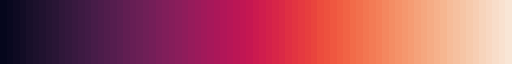

In [46]:
cmap = sns.color_palette("rocket", n_colors = len(bins))
palette = matplotlib.colors.ListedColormap(cmap)
palette

<>:58: SyntaxWarning: invalid escape sequence '\o'
<>:58: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_179134/424770434.py:58: SyntaxWarning: invalid escape sequence '\o'
  cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
/tmp/ipykernel_179134/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_179134/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_179134/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_179134/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_179134/1331995612.py:29: RuntimeWarning: di

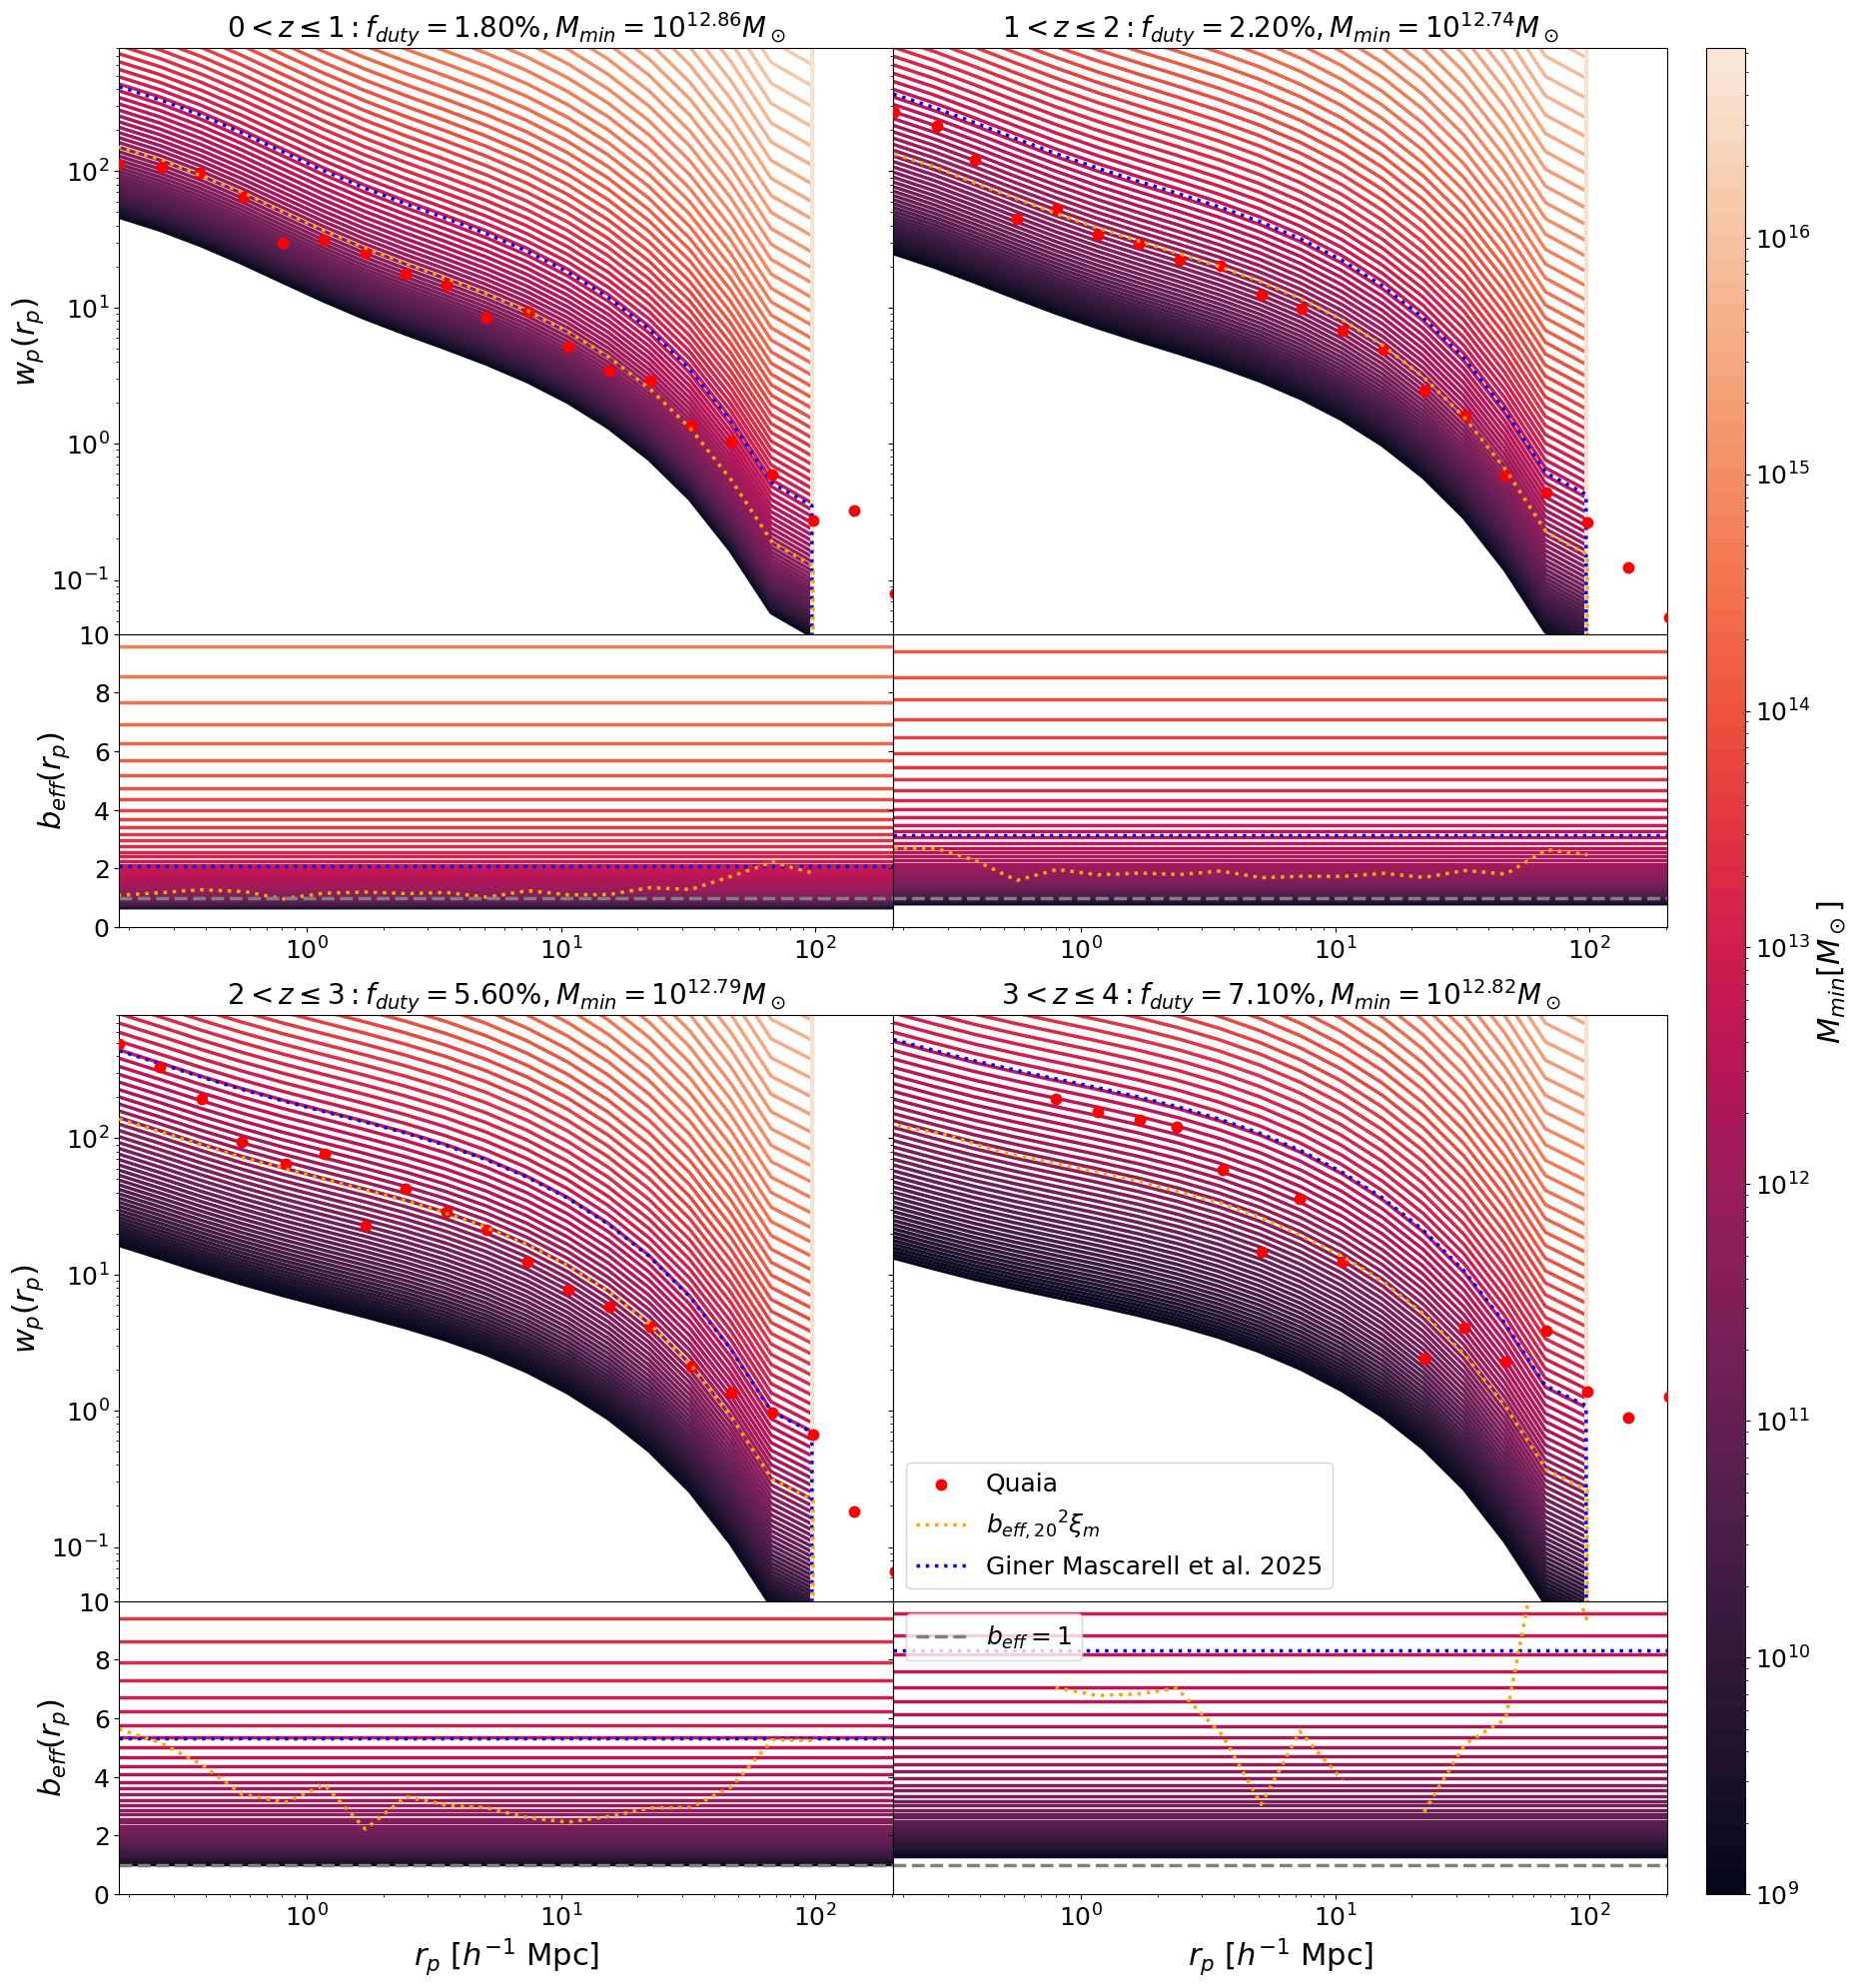

In [47]:
fig = plt.figure(figsize = (21, 24))
gs = gridspec.GridSpec(5, 4, height_ratios = [1, 0.5, 0.15, 1, 0.5], width_ratios = [1, 1, 0.05, 0.05], hspace = 0, wspace = 0)
ax1_idx = [0, 1, 12, 13]
ax2_idx = [4, 5, 16, 17]
k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[ax1_idx[j]])
    ax2 = fig.add_subplot(gs[ax2_idx[j]])
            
    ax1.scatter(rpavg_zbin_percentile[j], wp_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red', zorder = 3)    #color = cmap_b[j],
    ax1.plot(rpavg_zbin_percentile[j], b_eff_wp20[j]**2*wp_matter_zbin_percentile[j], linewidth = 2.5, label = r'${b_{eff, 20}}^2\xi_m$', color = 'orange', linestyle = ':', zorder = 3)

    for l in range(len(bins)):

        wp_2h_zbin, b_q = wp_2h(bins_M_min_array[l], n_m_array_2D[j][l], a_zbin[j], cosmo[fid], wp_matter_zbin_percentile[j], rpbins, pibins, recenter = False)
        ax1.plot(quaia.recenter(rpbins), wp_2h_zbin, color = cmap[l], linewidth = 2.5)
        ax2.axhline(b_q, color = cmap[l], linewidth = 2.5, zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
        
    wp_2h_zbin, b_q = wp_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo[fid], wp_matter_zbin_percentile[j], rpbins, pibins, recenter = False)
    ax1.plot(quaia.recenter(rpbins), wp_2h_zbin, linewidth = 2.5, color = 'blue', label = "Giner Mascarell et al. 2025", linestyle = ':')
    ax2.axhline(b_q, linewidth = 2.5, color = 'blue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

    ax2.plot(rpavg_zbin_percentile[j], b_wp[j], linewidth = 2.5, linestyle = ':', color = 'orange')

    if (j + k) % 6 < 2:
        ax1.set_title(r'${:.0f}<z \leq{:.0f}: f_{{duty}}={:.2f}\%, M_{{min}}=10^{{{:.2f}}} M_\odot$'.format(j, j+1, fduty[j]*100, M_min_array[j]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rpbins)[0], quaia.recenter(rpbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(4e-2, 8e2)

    ax2.axhline(1, linestyle = '--', color = 'grey', linewidth = 2.5, label = '$b_{eff}=1$')
    ax2.set_xlim(quaia.recenter(rpbins)[0], quaia.recenter(rpbins)[-1])
    ax2.set_ylim(0, 10)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$w_p(r_p)$')
        ax2.set_ylabel(r'$b_{eff}(r_p)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
            
    if j % 2 != 0:
        k+=4

ax1.legend()
ax2.legend()

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

# Calculate derived parameters
## Plot b(z)

In [48]:
def b_eboss(z):
    
    return 0.278*((1+z)**2-6.565) + 2.393

def b_quaia(b_0, a, cosmo = cosmo[fid]):
    
    return b_0/ccl.growth_factor(cosmo, a)

In [49]:
b_cf20 = np.load('../results/b_cf20.npy')
b_wp20 = np.load('../results/b_wp20.npy')

### Vary $M_{min}$

<>:44: SyntaxWarning: invalid escape sequence '\o'
<>:44: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_179134/1112372836.py:44: SyntaxWarning: invalid escape sequence '\o'
  cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
/tmp/ipykernel_179134/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_179134/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


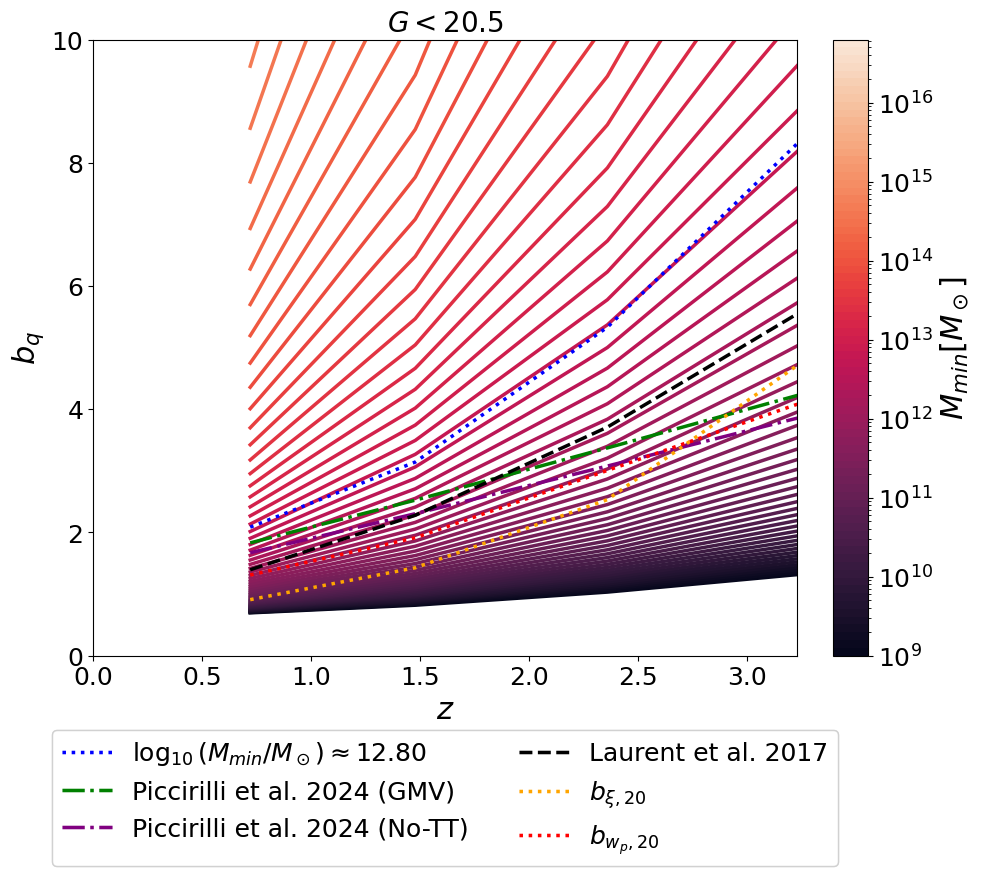

In [52]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])

for k in range(len(bins)):
    
    b_q = [wp_2h(bins_M_min_array[k], n_m_array_2D[j][k], a_zbin[j], cosmo[fid], wp_matter_zbin_percentile[j], rpbins, pibins,
                 recenter = False)[1] for j in z_array]
    zbin = 1/np.array(a_zbin)-1
    ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap[k]) #grey,
    
b_q = [wp_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo[fid], wp_matter_zbin_percentile[j], rpbins, pibins,
             recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'blue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
ax1.plot(zbin, b_quaia(1.26, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_quaia(1.15, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
         color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761

ax1.plot(zbin, b_cf20, linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
ax1.plot(zbin, b_wp20, linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

ax1.set_title('$G<{}$'.format(G_hi))

ax1.set_xlabel('$z$')
ax1.set_ylim(0, 10)
ax1.set_xlim(0, zbin[-1])
ax1.set_ylabel(r'$b_q$')

custom_lines = [Line2D([0], [0], color = 'blue', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx {:.2f}$'.format(M_min), 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 'Laurent et al. 2017',
                                          r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

## Calculate halo mass as $\langle M \rangle \approx n_q^{-1} \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle M$

### Vary $M_{min}$

<>:41: SyntaxWarning: invalid escape sequence '\o'
<>:41: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_179134/3790987215.py:41: SyntaxWarning: invalid escape sequence '\o'
  label = '$M_{min}[M_\odot]$')
/tmp/ipykernel_179134/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_179134/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


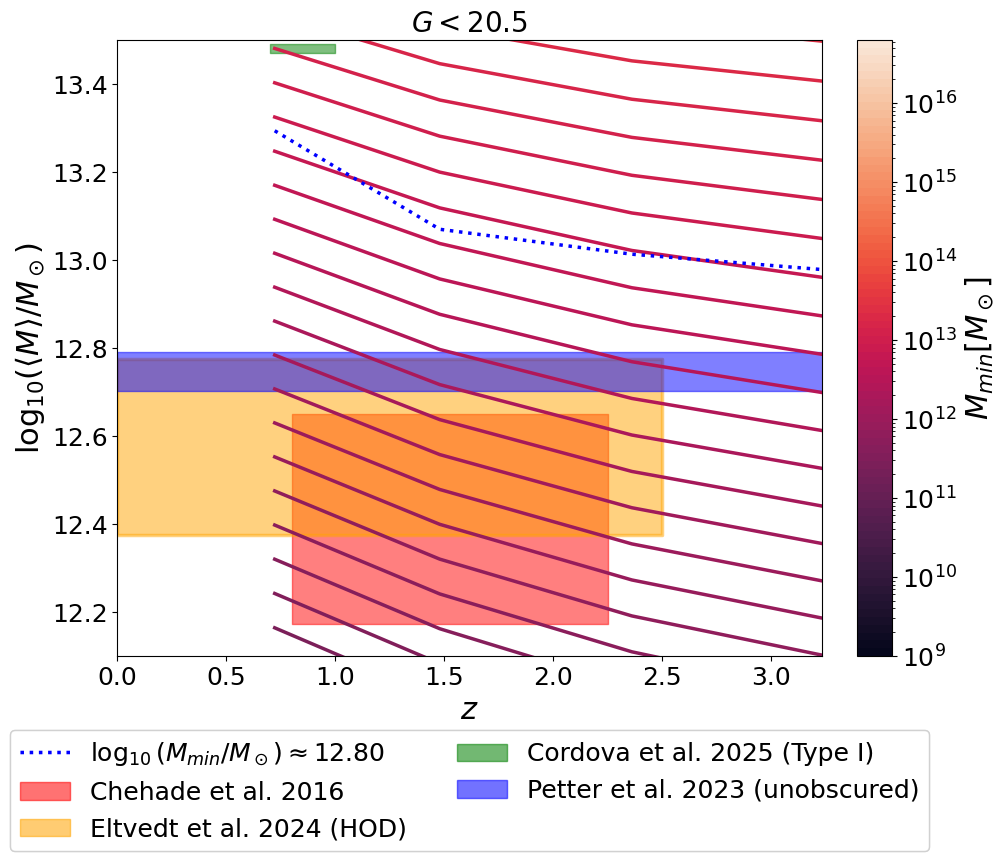

In [53]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
i = 1

for k in range(len(bins)):
    
    M_h = [M(bins_M_min_array[k], n_m_array_2D[j][k], a = a_zbin[j], cosmo = cosmo[fid], recenter = False)[0] for j in z_array]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, 
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
             color = cmap[k]) #, alpha = (1+k)/len(bins))
M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo[fid], recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'blue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
z = np.linspace(0.8, 2.25)
ax1.fill_between(z, [np.log10(1e12/cosmo[fid]['h'])]*len(z), [np.log10(3e12/cosmo[fid]['h'])]*len(z), alpha = 0.5, label = 'Chehade et al. 2016', 
                 color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/cosmo[fid]['h'])]*len(z), [np.log10(4e12/cosmo[fid]['h'])]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/cosmo[fid]['h'])]*len(z), [np.log10(10**12.62/cosmo[fid]['h'])]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = 'blue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min),
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(0, zbin[-1])
ax1.set_ylim(12.1, 13.5)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]),
                    label = '$M_{min}[M_\odot]$')
plt.show()

## Calculate number density as $n_q \approx \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle$

In [54]:
tab_datahi_mask_zbins, selfunc_hi_bins = [], []
for j in z_array:
    
    tab_datahi_mask_zbin0, _, _, _, _, _, selfunc_hi_bin0 = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)
    tab_datahi_mask_zbins.append(tab_datahi_mask_zbin0['redshift_quaia'])
    selfunc_hi_bins.append(selfunc_hi_bin0)

G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336
G20.5_zmin1.0zmax2.0: 0.28              467913 vs 648196
G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508
G20.5_zmin3.0zmax4.0: 0.21              28061 vs 35630


In [64]:
n_q, n_q_err = [], []

for j in z_array:
    
    N = len(tab_datahi_mask_zbins[j])
    cp = np.percentile(selfunc_hi_bins[j], mask*100)
    f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[j][selfunc_hi_bins[j]>=cp]*hp.nside2pixarea(NSIDE))
    print(f_sky)
    zmax = quaia.comoving_dist(j+1, h = cosmo[fid]['h'], Om0 = cosmo[fid]['Omega_m']).value # Mpc/h
    zmin = quaia.comoving_dist(j, h = cosmo[fid]['h'], Om0 = cosmo[fid]['Omega_m']).value # Mpc/h
    V = f_sky*(4/3*np.pi*(zmax**3-zmin**3)) #*cosmo_quaia['h']**3 # convert to 1/Mpc^3
    
    n_q.append(N/V)
    n_q_err.append(np.sqrt(N)/V) # Poisson error
    
    ### Compute the maximum number of jackknife regions
    V_jackknife = f_sky*(4/3*np.pi*(80**3))
    print('N_jackknife:', np.int(V/V_jackknife), (V/25)**(1/3),'\n')

0.29746390823822866
N_jackknife: 23522 843.5514925658293 

0.3229221159273539
N_jackknife: 66073 1223.250188159622 

0.2744938755620083
N_jackknife: 75000 1208.7563261466912 

0.2551523073813655
N_jackknife: 71020 1158.4256021659548 



### Test method against Storey-Fisher et al. 2023

In [71]:
tab_datahi_mask_zbin0, _, _, _, _, _, selfunc_hi_bin0 = quaia.make_bins(G_hi, [0], True, ['z'], 
                                                                                     bins = [None], tab_gcat_type = 'data',
                                                                                     method = [None], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)

Leaving tab_gcat_catalog unbinned
G20.5: 0.28              938957 vs 1295502


In [72]:
# cp = np.percentile(selfunc_hi_bin0, mask*100)
cp = 0
f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bin0[selfunc_hi_bin0>=cp]*hp.nside2pixarea(NSIDE))
print(f_sky)

0.4789816662703589


### Check against $V_{eff}$

In [73]:
r = quaia.comoving_dist(tab_datahi_mask_zbin0['redshift_quaia'], h = cosmo[fid]['h'], Om0 = cosmo[fid]['Omega_m'])
V = f_sky*(4/3*np.pi*(np.max(r)**3-np.min(r)**3))
V.to((u.Gpc/cu.littleh)**3) # i guess we expect a different result since kate said she calculated it differently?

<Quantity 284.75166624 Gpc3 / littleh3>

### Test method against Giner Mascarell et al. 2025

In [74]:
tab_datahi_mask_zbins, selfunc_hi_bins = [], []
b = [0,0,0,30]
for j in z_array:
    
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, selfunc_hi_bin0_mask_inv, _, selfunc_hi_bin0 = quaia.make_bins(G_hi, [j], True, ['z'],
                                                                                                                               mask_type = 'b', 
                                                                                                                               b = b[j],
                                                                                             bins = [z_bins], tab_gcat_type = 'data',
                                                                                             method = ['minmax'], fac_rand = 25,
                                                                                             n_bins = [None])
    tab_datahi_mask_zbins.append(tab_datahi_mask_zbin0['redshift_quaia'])
    selfunc_hi_bins.append(selfunc_hi_bin0)

G20.5_zmin0.0zmax1.0: 0.00              324336 vs 324336
G20.5_zmin1.0zmax2.0: 0.00              648196 vs 648196
G20.5_zmin2.0zmax3.0: 0.00              286508 vs 286508
G20.5_zmin3.0zmax4.0: 0.23              27584 vs 35630


In [75]:
n_q_b, n_q_b_err = np.array([])/V.unit, np.array([])/V.unit
b = [0,0,0,30]

for j in z_array:
    
    N = len(tab_datahi_mask_zbins[j])
    ra, dec = hp.pix2ang(NSIDE, range(len(selfunc_hi_bins[j])), lonlat = True)
    c = SkyCoord(ra=ra*u.degree, dec=dec*u.degree)
    mask_datahi_bin0 = np.abs(c.galactic.b.value)>=b[j]
    f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[j][mask_datahi_bin0]*hp.nside2pixarea(NSIDE))
    zmax = quaia.comoving_dist(j+1, h = cosmo[fid]['h'], Om0 = cosmo[fid]['Omega_m']) # Mpc/h
    zmin = quaia.comoving_dist(j, h = cosmo[fid]['h'], Om0 = cosmo[fid]['Omega_m']) # Mpc/h
    V = f_sky*(4/3*np.pi*(zmax**3-zmin**3)) 
    n_q_b = np.append(n_q_b,N/V)
    n_q_b_err = np.append(n_q_b_err,np.sqrt(N)/V) # Poisson error

### Try directly reproducing Giner Mascarell et al. 2025 constraints

In [76]:
zbin_eff = [0.5, 1.5, 2.5, 3.5]
a_eff = 1/(1+np.array(zbin_eff))
hmf08 = ccl.halos.MassFuncTinker08()

# convert to (h/Mpc)^3 jk its already in (h/Mpc)^3
n_dm = np.array([n_DM(cosmo[fid], a_eff[j], M_min_array[j], N = 100) for j in z_array])*(cu.littleh/u.Mpc)**3 
n_dm_08 = np.array([n_DM(cosmo[fid], a_eff[j], M_min_array[j], N = 100, hmf = hmf08) for j in z_array])*(cu.littleh/u.Mpc)**3 

In [77]:
n_dm2 = 8.158e-04, 4.645e-04,8.703e-05, 1.073e-05

In [78]:
n_dm_err_hi = 7.867e-05, 2.959e-05, 1.122e-05, 5.418e-06
n_dm_err_lo = 1.090e-04, 3.135e-05, 8.270e-06, 1.526e-05

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_179134/536990337.py:13: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('$n_{DM} [(h\mathrm{Mpc}^{-1})^3]$')
/tmp/ipykernel_179134/536990337.py:24: SyntaxWarning: invalid escape sequence '\D'
  ax2.set_ylabel('$\Delta n_{DM} [(h\mathrm{Mpc}^{-1})^3]$')


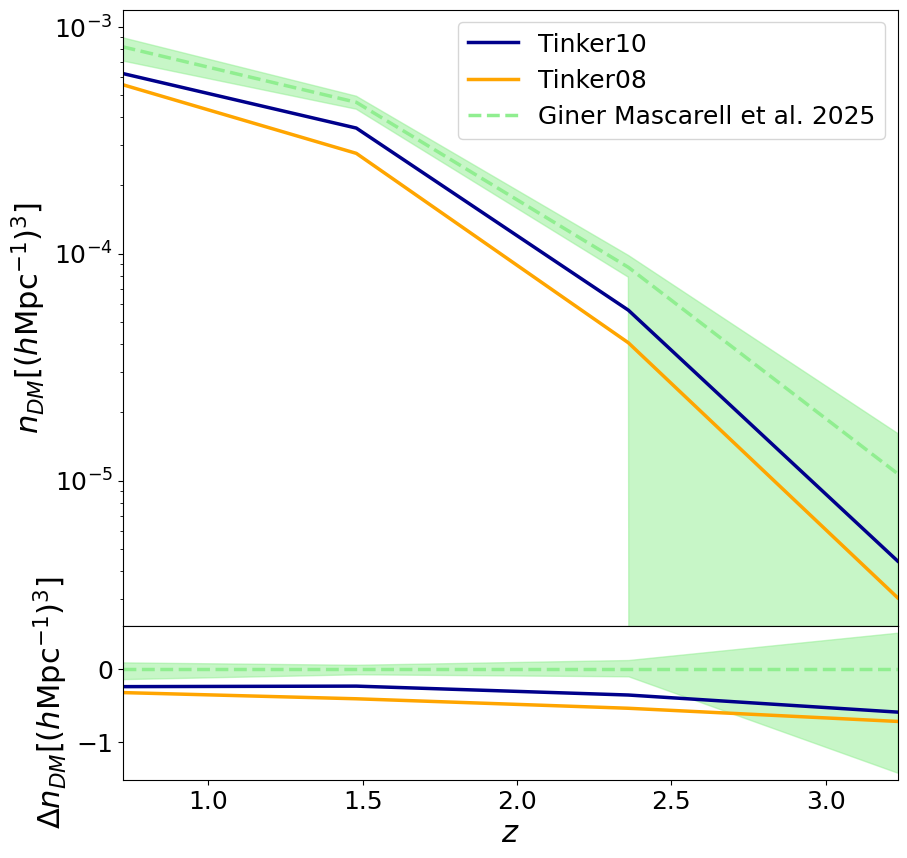

In [79]:
fig = plt.figure(figsize = (10, 10))
gs = gridspec.GridSpec(2, 1, height_ratios = [1, 0.25], hspace = 0, wspace = 0)

ax1 = fig.add_subplot(gs[0])

ax1.plot(zbin, n_dm, color = 'darkblue', linewidth = 2.5, label = 'Tinker10')
ax1.plot(zbin, n_dm_08, color = 'orange', linewidth = 2.5, label = 'Tinker08')
ax1.plot(zbin, n_dm2, label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')

n_dm_hi = np.add(n_dm2, n_dm_err_hi)
n_dm_lo = np.subtract(n_dm2, n_dm_err_lo)
ax1.fill_between(zbin, n_dm_hi, n_dm_lo, color = 'lightgreen', alpha = 0.5)
ax1.set_ylabel('$n_{DM} [(h\mathrm{Mpc}^{-1})^3]$')
ax1.set_xticklabels([])
ax1.legend()
ax1.set_xlim(zbin[0], zbin[-1])
ax1.set_yscale('log')

ax2 = fig.add_subplot(gs[1])
ax2.plot(zbin, (n_dm.value-n_dm2)/n_dm2, color = 'darkblue', linewidth = 2.5, label = 'Tinker10')
ax2.plot(zbin, (n_dm_08.value-n_dm2)/n_dm2, color = 'orange', linewidth = 2.5, label = 'Tinker08')
ax2.axhline(0, label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
ax2.fill_between(zbin, np.array(n_dm_err_hi)/n_dm2, -np.array(n_dm_err_lo)/n_dm2, color = 'lightgreen', alpha = 0.5)
ax2.set_ylabel('$\Delta n_{DM} [(h\mathrm{Mpc}^{-1})^3]$')
ax2.set_xlabel('$z$')
ax2.set_xlim(zbin[0], zbin[-1])
plt.show()

In [80]:
fduty_check = n_q_b/n_dm
fduty_check2 = n_q_b/n_dm2
fduty_check_08 = n_q_b/n_dm_08

In [81]:
print("\n--- Quasar duty cycle per redshift bin ---")
header = (f"{'bin':>5} {'z_eff':>6} "
          f"{'n_QSO [h^3/Mpc^3]':>24} {'n_DM [h^3/Mpc^3]':>32} "
          f"{'f_duty':>14}")
print(header)
print("-" * len(header))

for j in range(len(zbin_eff)):
    print(f"{j+1:3d} {zbin_eff[j]:6.1f} "
          f"{n_q_b[j].value:18.3e}"
          f" (+/-{n_q_b_err[j].value:.3e})"
          f" {n_dm[j].value:18.3e} "
          f"{fduty_check_08[j]:20.3f} ")


--- Quasar duty cycle per redshift bin ---
  bin  z_eff        n_QSO [h^3/Mpc^3]                 n_DM [h^3/Mpc^3]         f_duty
-------------------------------------------------------------------------------------
  1    0.5          1.481e-05 (+/-2.600e-08)          6.223e-04                0.027 
  2    1.5          1.013e-05 (+/-1.259e-08)          3.576e-04                0.037 
  3    2.5          4.783e-06 (+/-8.935e-09)          5.634e-05                0.118 
  4    3.5          7.203e-07 (+/-4.337e-09)          4.422e-06                0.236 


In [82]:
fduty_err_hi = 0.002, 0.001, 0.008, 0.077
fduty_err_lo = 0.002, 0.001, 0.007, 0.034

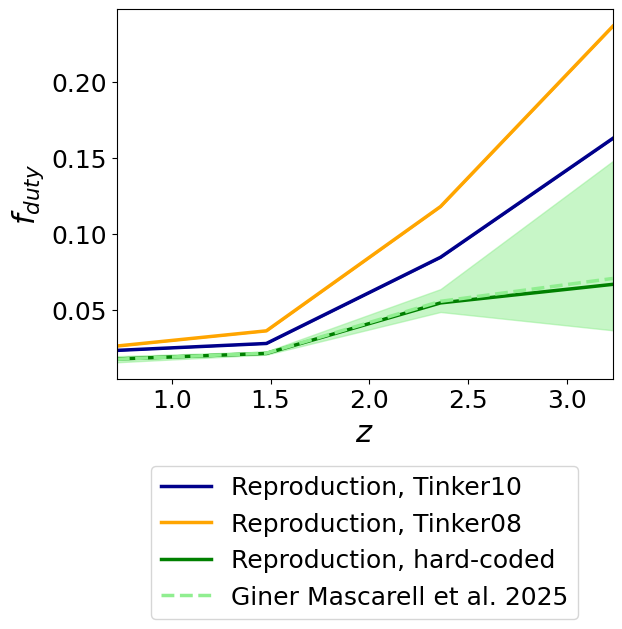

In [83]:
plt.plot(zbin, fduty_check, color = 'darkblue', linewidth = 2.5, label = 'Reproduction, Tinker10')
plt.fill_between(zbin, fduty_check+n_q_b_err.value, fduty_check-n_q_b_err.value, alpha = 0.5, color = 'darkblue')
plt.plot(zbin, fduty_check_08, color = 'orange', linewidth = 2.5, label = 'Reproduction, Tinker08')
plt.fill_between(zbin, fduty_check_08+n_q_b_err.value, fduty_check_08-n_q_b_err.value, alpha = 0.5, color = 'orange')
plt.plot(zbin, fduty_check2, color = 'green', linewidth = 2.5, label = 'Reproduction, hard-coded')
plt.plot(zbin, fduty, label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
plt.fill_between(zbin, np.array(fduty)+fduty_err_hi, np.array(fduty)-fduty_err_lo, alpha = 0.5, color = 'lightgreen')
plt.ylabel('$f_{duty}$')
plt.xlabel('$z$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(zbin[0], zbin[-1])
plt.show()

### Plot

In [84]:
n_q_hi = np.array(fduty)*n_dm_hi
n_q_lo = np.array(fduty)*n_dm_lo

In [85]:
n_q_err_hi = n_q_hi*np.sqrt((np.array(n_dm_err_hi)/n_dm2)**2+(fduty_err_hi/fduty_check2.value)**2)
n_q_err_lo = n_q_lo*np.sqrt((np.array(n_dm_err_lo)/n_dm2)**2+(fduty_err_lo/fduty_check2.value)**2)

In [86]:
M_min_err_hi = 0.04, 0.02, 0.03, 0.10
M_min_err_lo = 0.05, 0.02, 0.03, 0.12

In [87]:
bins_M_min_hi, bins_M_min_lo = [], []
for i in z_array:   
    bins_M_min_hi.append(np.logspace(M_min_array[i]+np.array(M_min_err_hi), 16.8, 79))
    bins_M_min_lo.append(np.logspace(M_min_array[i]-np.array(M_min_err_lo), 16.8, 79))

In [89]:
def n_q_theory_err(n_dm, fduty_err, M_min, a, M_min_err, hmf = hmf, cosmo = cosmo[fid]):
    
    nm = hmf(cosmo, bins/cosmo['h'], a)/cosmo['h']**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.sqrt(n_dm**2*fduty_err**2+(fduty_err*hmf(cosmo, 10**M_min/cosmo['h'], a))**2*M_min_err**2)

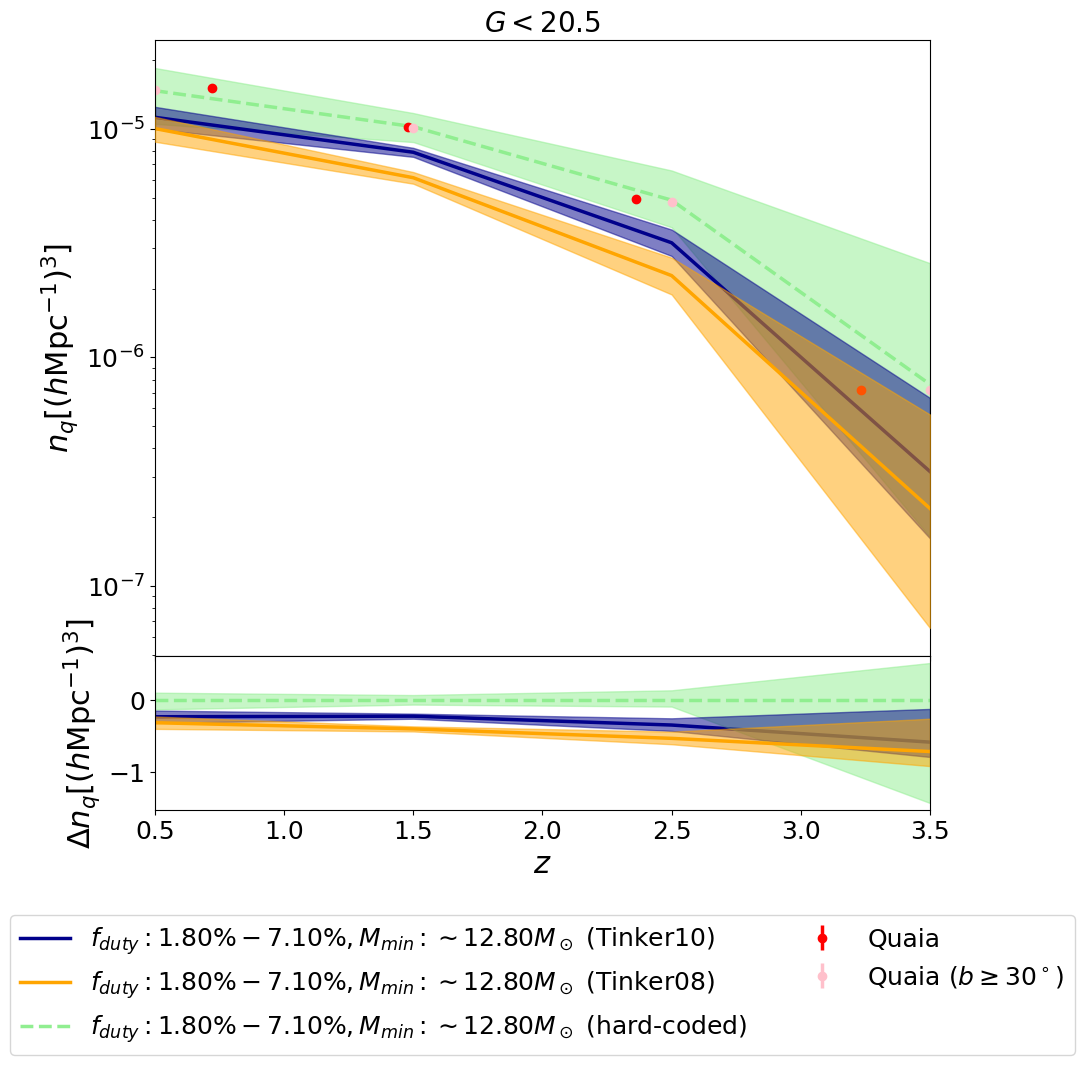

In [92]:
fig = plt.figure(figsize = (10, 10))
gs = gridspec.GridSpec(2, 1, height_ratios = [1, 0.25], hspace = 0, wspace = 0)

labels_cf = ['qq', r'$\xi_{2h}$']
i = 1

ax1 = fig.add_subplot(gs[0])

n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo[fid], recenter = False)[1] for j in z_array]
ax1.errorbar(zbin, n_q, linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = n_q_err, linestyle = 'None')
ax1.errorbar(zbin_eff, n_q_b, linewidth = 2.5, marker = 'o', label = r'Quaia $(b\geq 30^\circ)$', color = 'pink', linestyle = 'None', 
             yerr = n_q_b_err)

ax2 = fig.add_subplot(gs[1])
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_eff[j], cosmo = cosmo[fid], recenter = False)[1] for j in z_array]
n_q_theory_err_hi = [n_q_theory_err(n_dm.value[j], fduty_err_hi[j], M_min_array[j], a_eff[j], M_min_err_hi[j]) for j in z_array]
n_q_theory_err_lo = [n_q_theory_err(n_dm.value[j], fduty_err_lo[j], M_min_array[j], a_eff[j], M_min_err_lo[j]) for j in z_array]
n_q_theory_hi = np.add(n_q_theory,n_q_theory_err_hi)
n_q_theory_lo = n_q_theory-np.array(n_q_theory_err_lo)
ax1.plot(zbin_eff, n_q_theory, linewidth = 2.5, 
         label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:\sim{:.2f} M_\odot$ (Tinker10)'.format(fduty[0]*100, fduty[-1]*100, M_min), 
         color = 'darkblue')
ax1.fill_between(zbin_eff, n_q_theory_hi, n_q_theory_lo, alpha = 0.5, color = 'darkblue')

n_q2 = np.array(fduty)*n_dm2
ax2.plot(zbin_eff, (n_q_theory-n_q2)/n_q2, linewidth = 2.5, 
         label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:\sim{:.2f} M_\odot$ (Tinker10)'.format(fduty[0]*100, fduty[-1]*100, M_min), 
         color = 'darkblue', zorder = 0)
ax2.fill_between(zbin_eff, (n_q_theory_hi-n_q2)/n_q2, (n_q_theory_lo-n_q2)/n_q2, alpha = 0.5, color = 'darkblue')
        
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_eff[j], cosmo = cosmo[fid], recenter = False, hmf = hmf08)[1] for j in z_array]
n_q_theory_err_hi = [n_q_theory_err(n_dm.value[j], fduty_err_hi[j], M_min_array[j], a_eff[j], M_min_err_hi[j], hmf = hmf08) for j in z_array]
n_q_theory_err_lo = [n_q_theory_err(n_dm.value[j], fduty_err_lo[j], M_min_array[j], a_eff[j], M_min_err_lo[j], hmf = hmf08) for j in z_array]
n_q_theory_hi = np.add(n_q_theory,n_q_theory_err_hi)
n_q_theory_lo = n_q_theory-np.array(n_q_theory_err_lo)
ax1.plot(zbin_eff, n_q_theory, linewidth = 2.5, 
         label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:\sim{:.2f} M_\odot$ (Tinker08)'.format(fduty[0]*100, fduty[-1]*100, M_min), 
         color = 'orange')
ax1.fill_between(zbin_eff, n_q_theory_hi, n_q_theory_lo, alpha = 0.5, color = 'orange', zorder = 5)
ax2.plot(zbin_eff, (n_q_theory-n_q2)/n_q2, linewidth = 2.5, 
         label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:\sim{:.2f} M_\odot$ (Tinker08)'.format(fduty[0]*100, fduty[-1]*100, M_min), 
         color = 'orange')
ax2.fill_between(zbin_eff, (n_q_theory_hi-n_q2)/n_q2, (n_q_theory_lo-n_q2)/n_q2, alpha = 0.5, color = 'orange')

# np.array(fduty)*n_dm_hi
ax1.plot(zbin_eff, n_q2, linewidth = 2.5, linestyle = '--',
         label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:\sim{:.2f} M_\odot$ (hard-coded)'.format(fduty[0]*100, fduty[-1]*100, M_min),
         color = 'lightgreen', zorder = 0)
ax1.fill_between(zbin_eff, n_q_hi+n_q_err_hi, n_q_lo-n_q_err_lo, alpha = 0.5, color = 'lightgreen', zorder = 0)
ax2.axhline(0, linewidth = 2.5, linestyle = '--',
         label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:\sim{:.2f} M_\odot$ (hard-coded)'.format(fduty[0]*100, fduty[-1]*100, M_min),
         color = 'lightgreen', zorder = 0)
ax2.fill_between(zbin_eff, np.array(fduty)*n_dm_err_hi/n_q2, -np.array(fduty)*n_dm_err_lo/n_q2, alpha = 0.5, color = 'lightgreen', zorder = 0)

ax1.set_title('$G<{}$'.format(G_hi))

ax1.set_xticklabels([])
ax1.legend(bbox_to_anchor = (0.5, -0.4), loc='upper center', ncol = 2)
ax1.set_ylabel(r'$n_q [(h\mathrm{Mpc}^{-1})^3]$')
ax1.set_yscale('log')
ax1.set_xlim(zbin_eff[0], zbin_eff[-1])
                 
ax2.set_xlabel('$z$')
ax2.set_ylabel(r'$\Delta n_q[(h\mathrm{Mpc}^{-1})^3]$')
ax2.set_xlim(zbin_eff[0], zbin_eff[-1])

plt.show()

### Vary $M_{min}$

<>:32: SyntaxWarning: invalid escape sequence '\o'
<>:32: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_158387/1356760809.py:32: SyntaxWarning: invalid escape sequence '\o'
  cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_158387/1356760809.py:9: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),


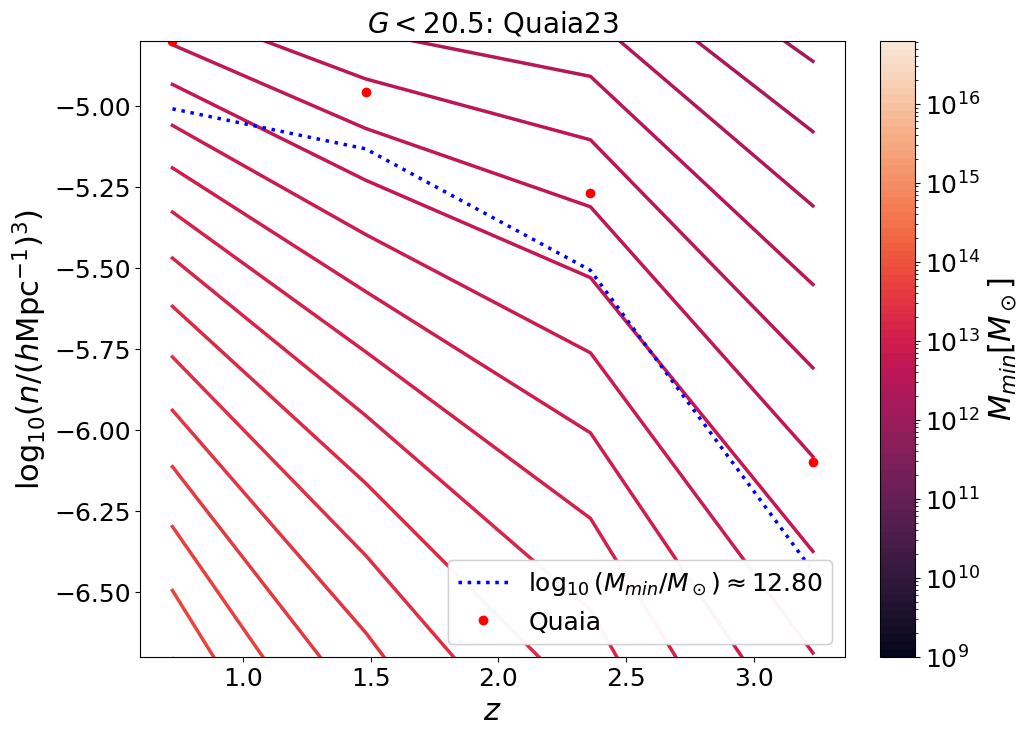

In [79]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])

for k in range(len(bins)):
    
    n_q_theory = [M(bins_M_min_array[k], n_m_array_2D[j][k], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1] for j in z_array]
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:[{:.2f}-{:.2f}] M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[0]), 
                                                                                                  np.log10(bins[-1])), color = cmap[k])
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1] for j in z_array]
ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'blue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

custom_lines = [Line2D([0], [0], color = 'blue', linestyle = ':', linewidth = 2.5, 
                       label = r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min)), 
                Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia')]
second_legend = ax1.legend(handles = custom_lines)
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
# plt.legend()
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(-6.7, -4.8)

# cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.BoundaryNorm(np.log10(bins), palette.N)), cax = fig.add_subplot(gs[:,-1]), label = '$\log_{10}(M_{min}/M_\odot)$')
cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

### Vary $f_{duty}$

In [80]:
fduty_array = np.logspace(-5,0, 51) #-4
n_m_array_3D = []
for i in z_array:

    n_m_array_3D.append([])
    
#     for j in range(len(bins)):
        
#         n_m_array_3D[i].append([])
        
    for k in range(len(fduty_array)):

        n_m=np.ones(np.shape(bins))*fduty_array[k]
        # n_m[quaia.recenter(bins)>=bins[j]]=fduty_array[k]
        n_m_array_3D[i].append(n_m)

<>:36: SyntaxWarning: invalid escape sequence '\o'
<>:36: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_158387/3582948278.py:36: SyntaxWarning: invalid escape sequence '\o'
  cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_158387/3582948278.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),


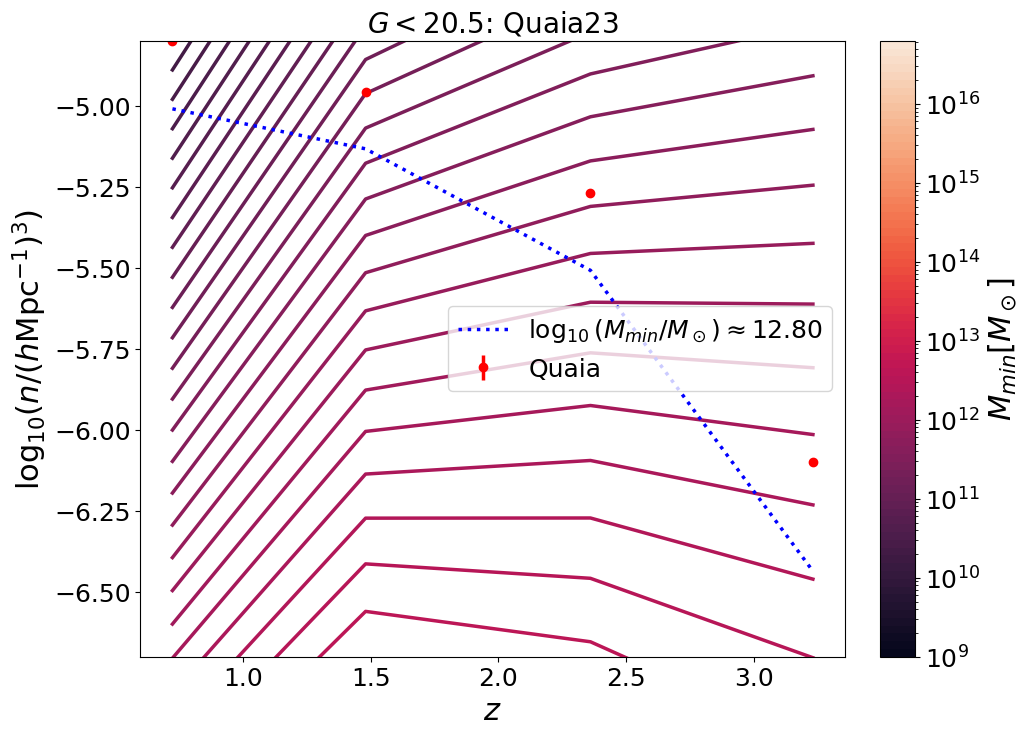

In [81]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
i = 1
# l = np.random.randint(0, len(fduty_array), size = len(z_array))
for k in range(len(bins)):
    
    n_q_theory = [M(bins_M_min_array[k], n_m_array_3D[j][f[j]], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1] for j in z_array]
    plt.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             # label = r'$f_{{duty}}: {:.2f}\%, M_{{min}}:[{:.2f}-{:.2f}] M_\odot$'.format(fduty_array[l]*100, np.log10(bins[0]), 
             #                                                                                      np.log10(bins[-1])), 
             color = cmap[k])
    
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1] for j in z_array]
ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'blue', linestyle = ':', 
         label = r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min)) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

# custom_lines = [Line2D([0], [0], color = grey, linestyle = '-', linewidth = 2.5, 
#                        label = r'$f_{{duty}}: [{:.2f}, {:.2f}, {:.2f}, {:.2f}]\%, M_{{min}}:[{:.2f}-{:.2f}] M_\odot$'.format(*fduty_array[f]*100, 
#                                                                                                             np.log10(bins[0]), np.log10(bins[-1]))), 
#                 Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia')]
# second_legend = ax1.legend(handles = custom_lines, bbox_to_anchor = (0.5, -0.1), loc='upper center')
# fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(-6.7, -4.8)
ax1.legend()

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

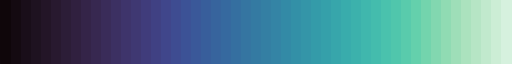

In [82]:
cmap_fduty = sns.color_palette("mako", n_colors = len(fduty_array))
palette_fduty = matplotlib.colors.ListedColormap(cmap_fduty)
palette_fduty

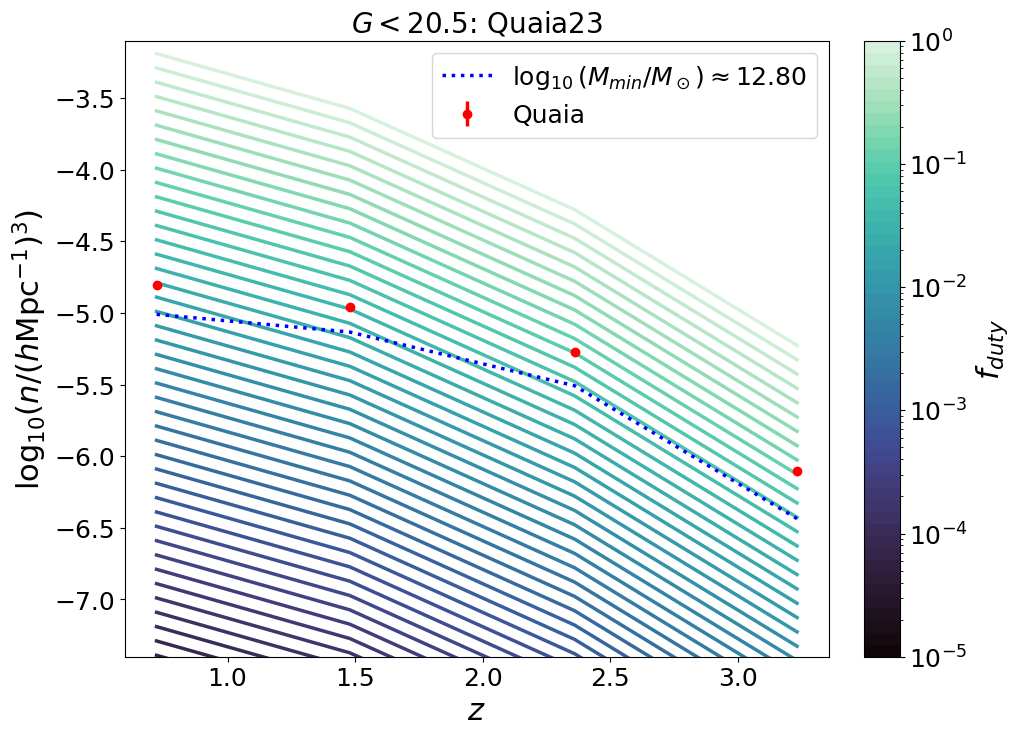

In [83]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
i = 1
l = 38

for k in range(len(fduty_array)):
    
    n_q_theory = [M(bins_M_min_array[l], n_m_array_3D[j][k], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1] for j in z_array]
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             color = cmap_fduty[k])
    
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1] for j in z_array]
ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'blue', linestyle = ':', 
         label = r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(np.log10(bins[l]))) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

# custom_lines = [Line2D([0], [0], color = 'blue', linestyle = ':', linewidth = 2.5, 
#                        label = '$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min)), 
#                 Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia')]
# second_legend = ax1.legend(handles = custom_lines, bbox_to_anchor = (0.5, -0.1), loc='upper center')
# fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
# plt.ylim(-6.7, -4.8)
ax1.set_ylim(-7.4, -3.1)
ax1.legend()

# cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_fduty, norm = matplotlib.colors.BoundaryNorm(np.log10(fduty_array), palette_fduty.N)), cax = fig.add_subplot(gs[:,-1]), label = '$\log_{10}(f_{duty})$')
cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_fduty, norm = matplotlib.colors.LogNorm(vmin=fduty_array[0], vmax = fduty_array[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$f_{duty}$')
plt.show()

# Perform $\chi^2$ fit
## $\chi_c^2=\sum \frac{\left(O_i-E_i\right)^2}{E_i}$

In [84]:
M_min_fit = []
for j in z_array:

    chi2 = []
    for m in bins:
        
        # n_m=np.zeros(np.shape(quaia.recenter(bins)))
        # n_m[quaia.recenter(bins)>=m]=fduty[j]
        n_m=np.ones(np.shape(bins))*fduty[j]
        bins_m = np.logspace(np.log10(m), 16.8, 79)
        
        cf_2h_zbin, b_q = cf_2h(bins_m, n_m, a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j], recenter = False)
        chi2_m = (cf_zbin_percentile[labels[i]][j]-cf_2h_zbin)**2/cf_2h_zbin
        chi2_m[np.isnan(cf_2h_zbin)]=np.inf
        
        chi2.append(np.nansum(chi2_m))

    k = np.argmin(chi2)
    print(chi2[k])
    M_min_fit.append(bins[k])

np.log10(M_min_fit)

166.5150368694704
86.08104822027445
85.99772140240816
138.6861025900827


/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


array([ 9. ,  9. , 10.3, 11. ])

## Limit scales to $10\geq s \geq 85h^{-1}$ Mpc

In [85]:
# Create the bins array
rmin = 10 # 0.1 # start higher # 1.4 # 30
rmax = 85 # 200
nbins = 20 #90 #20
rbins_chi2 = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
quaia.recenter(rbins_chi2)

array([10.56468968, 11.75784393, 13.08575056, 14.56362822, 16.20841434,
       18.0389592 , 20.07624203, 22.34361137, 24.86705273, 27.67548634,
       30.80109866, 34.27971118, 38.15119101, 42.45990779, 47.25524215,
       52.59215168, 58.53180075, 65.14226153, 72.49929411, 80.68721477])

In [86]:
cf_chi2, cf_matter_chi2 = {label: [] for label in labels}, {label: [] for label in labels}
yerr_cf_chi2, b_cf_chi2 = {label: [] for label in labels}, {label: [] for label in labels}
b_cf_q_chi2 = {label: [] for label in labels}
i = 1
    
for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _ = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)

    # quasar correlation function
    cf, qq, qr = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
               rbins = rbins_chi2, Om0 = Omega_m_array[i], h = h_array[i], error = True)
    cf_chi2[labels[i]].append(cf)

    # scale factor
    a = a_median(tab_datahi_mask_zbin0)

    # matter correlation function
    H0 = h_array[i]*100 * u.km/u.s/u.Mpc
    rbins_Mpc = (quaia.recenter(rbins_chi2)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
    cf_matter = ccl.correlations.correlation_3d(cosmos[i], r=rbins_Mpc, a=a)
    cf_matter_chi2[labels[i]].append(cf_matter)

    # effective bias 
    b = np.sqrt(cf/cf_matter)
    b_cf_chi2[labels[i]].append(b)

    # yerr
    yerr=(1+cf)/np.sqrt(qq)
    yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
    yerr_cf_chi2[labels[i]].append(yerr)

    # qso bias
    b_cf_q_chi2[labels[i]].append(b_qso(cf, cf_matter, ccl.growth_rate(cosmos[i], a)))

G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin1.0zmax2.0: 0.28              467913 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin3.0zmax4.0: 0.21              28061 vs 35630


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_158387/3288299834.py:28: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_158387/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


In [87]:
M_min_fit = []
for j in z_array:

    chi2 = []
    for m in bins:
        
#         n_m=np.zeros(np.shape(quaia.recenter(bins)))
#         n_m[quaia.recenter(bins)>=m]=fduty[j]
        n_m=np.ones(np.shape(bins))*fduty[j]
        bins_m = np.logspace(np.log10(m), 16.8, 79)
        
        cf_2h_zbin, b_q = cf_2h(bins_m, n_m, a_zbin[labels[i]][j], cosmos[i], cf_matter_chi2[labels[i]][j], recenter = False)
        # cf_2h_zbin, b_q = cf_2h(bins, n_m, a_zbin[labels[i]][j], cosmos[i], cf_matter_chi2[labels[i]][j])
        chi2_m = (cf_chi2[labels[i]][j]-cf_2h_zbin)**2/cf_2h_zbin
        chi2_m[np.isnan(cf_2h_zbin)]=np.inf
        
        chi2.append(np.sum(chi2_m))

    k = np.argmin(chi2)
    print(chi2[k])
    M_min_fit.append(bins[k])

np.log10(M_min_fit)

0.22055390738289693
0.10592235450599222
0.13647778294677193
2.7375960243494726


/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


array([11.5, 11.5, 11.7, 12.2])

## Enforce the number density constraint
### Vary $f_{duty}$

In [88]:
M_min_fit, fduty_fit = [], []
for j in z_array:

    chi2 = np.zeros((len(bins), len(fduty_array)))

    for k in range(len(fduty_array)):
        
        for l in range(len(bins)):
        
            # n_m=np.zeros(np.shape(quaia.recenter(bins)))
            # n_m[quaia.recenter(bins)>=bins[l]]=fduty_array[k]
            n_m=np.ones(np.shape(bins))*fduty_array[k]
            bins_m = np.logspace(np.log10(bins[l]), 16.8, 79)
        
            cf_2h_zbin, b_q = cf_2h(bins_m, n_m, a_zbin[labels[i]][j], cosmos[i], cf_matter_chi2[labels[i]][j], recenter = False)
            # cf_2h_zbin, b_q = cf_2h(bins, n_m, a_zbin[labels[i]][j], cosmos[i], cf_matter_chi2[labels[i]][j])
            chi2_m = (cf_chi2[labels[i]][j]-cf_2h_zbin)**2/cf_2h_zbin
            # chi2_m[np.isnan(cf_2h_zbin)]=np.inf
            chi2_m[np.isnan(chi2_m)]=np.inf
            chi2[l,k]=np.sum(chi2_m)

    ind = np.unravel_index(np.argmin(chi2), chi2.shape)
    print(chi2[ind])
    M_min_fit.append(bins[ind[0]])
    fduty_fit.append(fduty_array[ind[-1]])

np.log10(M_min_fit), np.log10(fduty_fit)

/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


0.22055390738289687
0.10592235450599218
0.1364777829467719
2.7375960243494726


/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: overflow encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_158387/3420925351.py:17: RuntimeWarning: invalid value encountered in divide
  chi2_m = (cf_chi2[labels[i]][j]-cf_2h_zbin)**2/cf_2h_zbin


(array([11.5, 11.5, 11.7, 12.2]), array([-4.3, -4.8, -5. , -4.9]))

### Enforce a hard limit on $n_q$

In [89]:
M_min_fit, fduty_fit = [], []
for j in z_array:

    chi2 = np.zeros((len(bins), len(fduty_array)))

    for k in range(len(fduty_array)):
        
        for l in range(len(bins)):
        
            n_m=np.ones(np.shape(bins))*fduty_array[k]
            bins_m = np.logspace(np.log10(bins[l]), 16.8, 79)
            
            cf_2h_zbin, b_q = cf_2h(bins_m, n_m, a_zbin[labels[i]][j], cosmos[i], cf_matter_chi2[labels[i]][j], recenter = False)
            chi2_m = (cf_chi2[labels[i]][j]-cf_2h_zbin)**2/cf_2h_zbin
            chi2_m[np.isnan(chi2_m)]=np.inf

            n_q_theory = M(bins_m, n_m, a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1]
            if np.abs(n_q_theory-n_q[j])/n_q[j]>=0.05:
                chi2_m = np.inf
            chi2[l,k]=np.sum(chi2_m)

    ind = np.unravel_index(np.argmin(chi2), chi2.shape)
    print(chi2[ind])
    M_min_fit.append(bins[ind[0]])
    fduty_fit.append(fduty_array[ind[-1]])

np.log10(M_min_fit), np.log10(fduty_fit)

/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


0.22055390738289693
0.10592235450599218
0.13647778294677193
2.7375960243494726


/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: overflow encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_158387/1067249660.py:14: RuntimeWarning: invalid value encountered in divide
  chi2_m = (cf_chi2[labels[i]][j]-cf_2h_zbin)**2/cf_2h_zbin


(array([11.5, 11.5, 11.7, 12.2]), array([-3. , -3.1, -2.9, -2.4]))

## Try unweighted version: $\chi_c^2=\sum {\left(O_i-E_i\right)^2}$

In [90]:
M_min_fit, fduty_fit = [], []
for j in z_array:

    chi2 = np.zeros((len(bins), len(fduty_array)))

    for k in range(len(fduty_array)):
        
        for l in range(len(bins)):
        
            n_m=np.ones(np.shape(bins))*fduty_array[k]
            bins_m = np.logspace(np.log10(bins[l]), 16.8, 79)
            
            cf_2h_zbin, b_q = cf_2h(bins_m, n_m, a_zbin[labels[i]][j], cosmos[i], cf_matter_chi2[labels[i]][j], recenter = False)
            chi2_m = (cf_chi2[labels[i]][j]-cf_2h_zbin)**2
            chi2_m[np.isnan(chi2_m)]=np.inf

            n_q_theory = M(bins_m, n_m, a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1]
            if np.abs(n_q_theory-n_q[j])/n_q[j]>=0.05:
                chi2_m = np.inf
            chi2[l,k]=np.sum(chi2_m)

    ind = np.unravel_index(np.argmin(chi2), chi2.shape)
    print(chi2[ind])
    M_min_fit.append(bins[ind[0]])
    fduty_fit.append(fduty_array[ind[-1]])

np.log10(M_min_fit), np.log10(fduty_fit)

/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


0.005769151655897091
0.00360458781942536
0.012148948634732818
0.4253866676390185


/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: overflow encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)


(array([11.1, 11.3, 11.4, 12. ]), array([-3.4, -3.3, -3.3, -2.8]))

## Try weighted version: $\chi_c^2=\sum \frac{\left(O_i-E_i\right)^2}{\sigma_i^2}$
### Using Poisson variance

In [91]:
M_min_fit, fduty_fit = [], []
for j in z_array:

    chi2 = np.zeros((len(bins), len(fduty_array)))

    for k in range(len(fduty_array)):
        
        for l in range(len(bins)):
        
            n_m=np.ones(np.shape(bins))*fduty_array[k]
            bins_m = np.logspace(np.log10(bins[l]), 16.8, 79)
            
            cf_2h_zbin, b_q = cf_2h(bins_m, n_m, a_zbin[labels[i]][j], cosmos[i], cf_matter_chi2[labels[i]][j], recenter = False)
            chi2_m = (cf_chi2[labels[i]][j]-cf_2h_zbin)**2/yerr_cf_chi2[labels[i]][j]**2
            chi2_m[np.isnan(chi2_m)]=np.inf

            n_q_theory = M(bins_m, n_m, a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1]
            if np.abs(n_q_theory-n_q[j])/n_q[j]>=0.05:
                chi2_m = np.inf
            chi2[l,k]=np.sum(chi2_m)

    ind = np.unravel_index(np.argmin(chi2), chi2.shape)
    print(chi2[ind])
    M_min_fit.append(bins[ind[0]])
    fduty_fit.append(fduty_array[ind[-1]])

np.log10(M_min_fit), np.log10(fduty_fit)

/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


185.62852050711564
167.75114711602015
77.6593784910322
inf


/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: overflow encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)


(array([11.4, 11.5, 11.7,  9. ]), array([-3.1, -3.1, -2.9, -5. ]))

## Try scipy.minimize

In [92]:
def f0(x, a, cf_matter, yerr_cf, cf, cosmo = cosmo_quaia):
    
    fduty, M_min = x
    
    bins_m = np.logspace(M_min, 16.8, 79)
    n_m=np.ones(np.shape(bins_m))*fduty
        
    cf_2h_zbin, b_q = cf_2h(bins_m, n_m, a, cosmo, cf_matter, recenter = False)
    
    return np.sum((cf-cf_2h_zbin)**2/yerr_cf**2)

### Add a number density constraint

In [93]:
def constraint(x, a, n_q, cosmo = cosmo_quaia, error = 0.05):
    
    fduty, M_min = x
    
    bins_m = np.logspace(M_min, 16.8, 79)
    n_m=np.ones(np.shape(bins_m))*fduty
    
    n_q_theory = M(bins_m, n_m, a = a, cosmo = cosmo, recenter = False)[1]

    return error-np.abs(n_q_theory-n_q)/n_q

In [94]:
i = 1
errors = [0.01, 0.01, 0.01, 0.01]
res, M_min_fit, fduty_fit = [], [], []
for j in z_array:

    fun = lambda x: f0(x, a_zbin[labels[i]][j], cf_matter_chi2[labels[i]][j], yerr_cf_chi2[labels[i]][j], 
                                  cf_chi2[labels[i]][j])
    cons = ({'type': 'ineq', 'fun': lambda x: constraint(x, a_zbin[labels[i]][j], n_q[j], error = errors[j])})
    
    res.append(minimize(fun, [fduty[j], M_min_array[j]], bounds = ((0,1), (9, 15)), constraints = cons))
    M_min_fit.append(10**res[j].x[-1])
    fduty_fit.append(res[j].x[0])
    
np.log10(M_min_fit), np.log10(fduty_fit), res

/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


(array([11.43685735, 11.48754772, 11.69737864, 12.82      ]),
 array([-3.06623221, -3.09826959, -2.90821301, -1.14874165]),
 [ message: Optimization terminated successfully
   success: True
    status: 0
       fun: 185.239958643413
         x: [ 8.586e-04  1.144e+01]
       nit: 11
       jac: [ 0.000e+00 -1.277e-02]
      nfev: 39
      njev: 11,
   message: Optimization terminated successfully
   success: True
    status: 0
       fun: 167.5772062652276
         x: [ 7.975e-04  1.149e+01]
       nit: 11
       jac: [ 0.000e+00 -3.738e-04]
      nfev: 39
      njev: 11,
   message: Optimization terminated successfully
   success: True
    status: 0
       fun: 77.65316263901667
         x: [ 1.235e-03  1.170e+01]
       nit: 10
       jac: [ 0.000e+00  9.766e-04]
      nfev: 33
      njev: 10,
   message: Inequality constraints incompatible
   success: False
    status: 4
       fun: nan
         x: [ 7.100e-02  1.282e+01]
       nit: 1
       jac: [       nan        nan]
      nfev:

## Use the jackknife variance

In [95]:
i = 1
errors = [0.05, 0.05, 0.05, 0.05]
res, M_min_fit, fduty_fit = [], [], []
for j in z_array:
    
    sigma = np.load('../results/sigma_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}.npy'.format(G_hi, rmin, rmax, nbins, j))

    fun = lambda x: f0(x, a_zbin[labels[i]][j], cf_matter_chi2[labels[i]][j], sigma, cf_chi2[labels[i]][j])
    cons = ({'type': 'ineq', 'fun': lambda x: constraint(x, a_zbin[labels[i]][j], n_q[j], error = errors[j])})
    
    res.append(minimize(fun, [fduty[j], M_min_array[j]], bounds = ((0,1), (9, 15)), constraints = cons))
    M_min_fit.append(10**res[j].x[-1])
    fduty_fit.append(res[j].x[0])
    
np.log10(M_min_fit), np.log10(fduty_fit), res

/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


(array([11.42858106, 11.5137517 , 11.70560497, 11.87715175]),
 array([-3.09205184, -3.08753441, -2.91475457, -3.03984364]),
 [ message: Optimization terminated successfully
   success: True
    status: 0
       fun: 94.5996844661655
         x: [ 8.090e-04  1.143e+01]
       nit: 9
       jac: [ 0.000e+00 -1.287e-04]
      nfev: 29
      njev: 9,
   message: Optimization terminated successfully
   success: True
    status: 0
       fun: 75.40267936386383
         x: [ 8.175e-04  1.151e+01]
       nit: 8
       jac: [ 0.000e+00 -2.995e-03]
      nfev: 26
      njev: 8,
   message: Optimization terminated successfully
   success: True
    status: 0
       fun: 43.63288276663365
         x: [ 1.217e-03  1.171e+01]
       nit: 10
       jac: [-4.768e-07  3.667e-04]
      nfev: 33
      njev: 10,
   message: Optimization terminated successfully
   success: True
    status: 0
       fun: 26.1480957967704
         x: [ 9.123e-04  1.188e+01]
       nit: 9
       jac: [ 0.000e+00 -5.293e-05]
  

## Limit scales to $30\geq s \geq 80h^{-1}$ Mpc

In [96]:
# Create the bins array
rmin = 30 # 0.1 # start higher # 1.4 # 30
rmax = 80 # 200
nbins = 20 #90 #20
rbins_chi2 = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'linear'
quaia.recenter(rbins_chi2)

array([31.25, 33.75, 36.25, 38.75, 41.25, 43.75, 46.25, 48.75, 51.25,
       53.75, 56.25, 58.75, 61.25, 63.75, 66.25, 68.75, 71.25, 73.75,
       76.25, 78.75])

In [97]:
cf_chi2, cf_matter_chi2 = {label: [] for label in labels}, {label: [] for label in labels}
yerr_cf_chi2, b_cf_chi2 = {label: [] for label in labels}, {label: [] for label in labels}
b_cf_q_chi2 = {label: [] for label in labels}
i = 1
    
for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _ = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)

    # quasar correlation function
    cf, qq, qr = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
               rbins = rbins_chi2, Om0 = Omega_m_array[i], h = h_array[i], error = True)
    cf_chi2[labels[i]].append(cf)

    # scale factor
    a = a_median(tab_datahi_mask_zbin0)

    # matter correlation function
    H0 = h_array[i]*100 * u.km/u.s/u.Mpc
    rbins_Mpc = (quaia.recenter(rbins_chi2)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
    cf_matter = ccl.correlations.correlation_3d(cosmos[i], r=rbins_Mpc, a=a)
    cf_matter_chi2[labels[i]].append(cf_matter)

    # effective bias 
    b = np.sqrt(cf/cf_matter)
    b_cf_chi2[labels[i]].append(b)

    # yerr
    yerr=(1+cf)/np.sqrt(qq)
    yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
    yerr_cf_chi2[labels[i]].append(yerr)

    # qso bias
    b_cf_q_chi2[labels[i]].append(b_qso(cf, cf_matter, ccl.growth_rate(cosmos[i], a)))

G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin1.0zmax2.0: 0.28              467913 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_158387/3288299834.py:28: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_158387/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


G20.5_zmin3.0zmax4.0: 0.21              28061 vs 35630


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_158387/3288299834.py:28: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_158387/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


In [135]:
i = 1
errors = [0.05, 0.05, 0.05, 0.05]
res, M_min_fit, fduty_fit = [], [], []
for j in z_array:
    
    # sigma = np.load('../results/sigma_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}.npy'.format(G_hi, rmin, rmax, nbins, j))
    sigma = np.sqrt(np.diag(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))))

    fun = lambda x: f0(x, a_zbin[labels[i]][j], cf_matter_chi2[labels[i]][j], sigma, cf_chi2[labels[i]][j])
    cons = ({'type': 'ineq', 'fun': lambda x: constraint(x, a_zbin[labels[i]][j], n_q[j], error = errors[j])})
    
    res.append(minimize(fun, [fduty[j], M_min_array[j]], bounds = ((0,1), (9, 15)), constraints = cons))
    M_min_fit.append(10**res[j].x[-1])
    fduty_fit.append(res[j].x[0])
    
np.log10(M_min_fit), np.log10(fduty_fit), res

/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


(array([12.17127552, 12.00405111, 12.09251409, 12.11885683]),
 array([-2.3502596 , -2.52174269, -2.30149187, -2.57630101]),
 [ message: Optimization terminated successfully
   success: True
    status: 0
       fun: 24.329515265310494
         x: [ 4.464e-03  1.217e+01]
       nit: 6
       jac: [ 0.000e+00  8.299e-03]
      nfev: 22
      njev: 6,
   message: Optimization terminated successfully
   success: True
    status: 0
       fun: 26.936026327461345
         x: [ 3.008e-03  1.200e+01]
       nit: 9
       jac: [ 0.000e+00 -1.626e-02]
      nfev: 33
      njev: 9,
   message: Optimization terminated successfully
   success: True
    status: 0
       fun: 16.513909868252593
         x: [ 4.995e-03  1.209e+01]
       nit: 10
       jac: [ 2.384e-07  3.500e-04]
      nfev: 35
      njev: 10,
   message: Optimization terminated successfully
   success: True
    status: 0
       fun: 19.474340649493563
         x: [ 2.653e-03  1.212e+01]
       nit: 8
       jac: [ 0.000e+00 -2.537e-

In [141]:
df = nbins-len(x)

for j in z_array:
    
    print('{}<z<={}'.format(j, j+1))
    x = fduty_fit[j], np.log10(M_min_fit[j])
    
    # sigma = np.load('../results/sigma_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}.npy'.format(G_hi, rmin, rmax, nbins, j))
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))
    sigma = np.sqrt(np.diag(C))
    chi2 = f0(x, a_zbin[labels[i]][j], cf_matter_chi2[labels[i]][j], sigma, cf_chi2[labels[i]][j])
    
    print('           chi^2: {:.2f}'.format(chi2))
    print('   reduced chi^2: {:.2f}'.format(chi2/df))
    print('         delta n: {:.2e}'.format(constraint(x, a_zbin[labels[i]][j], n_q[j], error = errors[j])))
    print('condition number: {:.2f}'.format(np.linalg.cond(C)))
    print('             PTE: {:.2f}\n'.format(stats.chi2.sf(chi2, df)))

0<z<=1
           chi^2: 24.33
   reduced chi^2: 1.35
         delta n: 1.09e-07
condition number: 1077.63
             PTE: 0.14

1<z<=2
           chi^2: 26.94
   reduced chi^2: 1.50
         delta n: -6.57e-09
condition number: 569.83
             PTE: 0.08

2<z<=3
           chi^2: 16.51
   reduced chi^2: 0.92
         delta n: 6.03e-03
condition number: 1043.11
             PTE: 0.56

3<z<=4
           chi^2: 19.47
   reduced chi^2: 1.08
         delta n: 2.63e-04
condition number: 987.01
             PTE: 0.36



## Use the full covariance matrix

In [100]:
def f0_GLS(x, a, cf_matter, C, cf, n_q, cosmo = cosmo_quaia, error = 0.05, constraint = True):
    
    fduty, M_min = x
    
    bins_m = np.logspace(M_min, 16.8, 79)
    n_m=np.ones(np.shape(bins_m))*fduty
        
    cf_2h_zbin, _ = cf_2h(bins_m, n_m, a, cosmo, cf_matter, recenter = False)

    if constraint == False:
        n_q_theory = M(bins_m, n_m, a = a, cosmo = cosmo, recenter = False)[1]
        penalty = (n_q_theory-n_q)**2/(error*n_q)
    else:
        penalty = 0
        
    return (cf-cf_2h_zbin).T @ np.linalg.inv(C) @ (cf-cf_2h_zbin)+penalty

In [101]:
fduty_guess = [0.018, 0.022, 0.056, 0.071]
M_min_guess = [12.86, 12.74, 12.79, 14]

In [145]:
i = 1
# errors = [0.2, 0.2, 0.2, 0.2]
error = 0.1
res, M_min_fit, fduty_fit = [], [], []
for j in z_array:
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))
    # C*= np.identity(len(C))
    
    fun = lambda x: f0_GLS(x, a_zbin[labels[i]][j], cf_matter_chi2[labels[i]][j], C, cf_chi2[labels[i]][j], n_q[j], error = error)
    cons = ({'type': 'ineq', 'fun': lambda x: constraint(x, a_zbin[labels[i]][j], n_q[j], error = error)}) 
    
    res.append(minimize(fun, [fduty_guess[j], M_min_guess[j]], bounds = ((0,1), (9, 15)), constraints = cons, method = 'trust-constr', options = {'maxiter': 2000}))
    M_min_fit.append(10**res[j].x[-1])
    fduty_fit.append(res[j].x[0])
    
np.log10(M_min_fit), np.log10(fduty_fit), res

(array([12.56690178, 12.07383459, 12.08934732, 11.45992537]),
 array([-1.8914047 , -2.41331505, -2.32520475, -3.75998685]),
 [           message: `xtol` termination condition is satisfied.
             success: True
              status: 2
                 fun: 164.13018975356644
                   x: [ 1.284e-02  1.257e+01]
                 nit: 165
                nfev: 852
                njev: 284
                nhev: 0
            cg_niter: 190
        cg_stop_cond: 2
                grad: [-3.815e-06  1.482e-01]
     lagrangian_grad: [-5.429e-04  1.384e-02]
              constr: [array([ 1.000e-01]), array([ 1.284e-02,  1.257e+01])]
                 jac: [array([[-6.705e+01, -2.666e+00]]), array([[ 1.000e+00,  0.000e+00],
                             [ 0.000e+00,  1.000e+00]])]
         constr_nfev: [852, 0]
         constr_njev: [0, 0]
         constr_nhev: [0, 0]
                   v: [array([ 4.912e-02]), array([ 3.293e+00, -3.425e-03])]
              method: tr_interior_poin

In [148]:
for j in z_array:
    
    print('{}<z<={}'.format(j, j+1))
    x = fduty_fit[j], np.log10(M_min_fit[j])
    
    # sigma = np.load('../results/sigma_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}.npy'.format(G_hi, rmin, rmax, nbins, j))
    # print('        chi^2:', f0(x, a_zbin[labels[i]][j], cf_matter_chi2[labels[i]][j], sigma, cf_chi2[labels[i]][j]))
    # print('reduced chi^2:', f0(x, a_zbin[labels[i]][j], cf_matter_chi2[labels[i]][j], sigma, cf_chi2[labels[i]][j])/18,'\n')
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))
    # C*= np.identity(len(C))
    chi2 = f0_GLS(x, a_zbin[labels[i]][j], cf_matter_chi2[labels[i]][j], C, cf_chi2[labels[i]][j], n_q[j], error = error)
    
    print('           chi^2: {:.2f}'.format(chi2))
    print('   reduced chi^2: {:.2f}'.format(chi2/df))
    print('         delta n: {:.2e}'.format(constraint(x, a_zbin[labels[i]][j], n_q[j], error = errors[j])))
    print('condition number: {:.2f}'.format(np.linalg.cond(C)))
    print('             PTE: {:.2e}\n'.format(stats.chi2.sf(chi2, df)))

0<z<=1
           chi^2: 164.13
   reduced chi^2: 9.12
         delta n: 5.00e-02
condition number: 1077.63
             PTE: 1.29e-25

1<z<=2
           chi^2: 49.60
   reduced chi^2: 2.76
         delta n: 5.00e-02
condition number: 569.83
             PTE: 8.66e-05

2<z<=3
           chi^2: 216.18
   reduced chi^2: 12.01
         delta n: 5.00e-02
condition number: 1043.11
             PTE: 5.69e-36

3<z<=4
           chi^2: 401.91
   reduced chi^2: 22.33
         delta n: -4.98e-02
condition number: 987.01
             PTE: 3.65e-74



In [104]:
# M_min_fit, fduty_fit = [], []
chi2_grid = {j: np.zeros((len(bins), len(fduty_array))) for j in z_array}
cons_grid = {j: np.zeros((len(bins), len(fduty_array))) for j in z_array}
for j in z_array:

    # chi2 = np.zeros((len(bins), len(fduty_array)))

    for k in range(len(fduty_array)):
        
        for l in range(len(bins)):
        
            # n_m=np.ones(np.shape(bins))*fduty_array[k]
            # bins_m = np.logspace(np.log10(bins[l]), 16.8, 79)
            
            x = fduty_array[k], np.log10(bins[l])

            C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))

            chi2_m = f0_GLS(x, a_zbin[labels[i]][j], cf_matter_chi2[labels[i]][j], C, cf_chi2[labels[i]][j], n_q[j], error = error)
            chi2_grid[j][l,k]=chi2_m
            
            # cf_2h_zbin, b_q = cf_2h(bins_m, n_m, a_zbin[labels[i]][j], cosmos[i], cf_matter_chi2[labels[i]][j], recenter = False)
            # chi2_m = (cf_chi2[labels[i]][j]-cf_2h_zbin)**2/yerr_cf_chi2[labels[i]][j]**2
            # chi2_m[np.isnan(chi2_m)]=np.inf

            # n_q_theory = M(bins_m, n_m, a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1]
            cons = constraint(x, a_zbin[labels[i]][j], n_q[j], error = error)
            cons_grid[j][l,k]=cons
            # if np.abs(n_q_theory-n_q[j])/n_q[j]>=error:
            #     chi2_m = np.inf

    # ind = np.unravel_index(np.argmin(chi2), chi2.shape)
    # print(chi2[ind])
    # M_min_fit.append(bins[ind[0]])
    # fduty_fit.append(fduty_array[ind[-1]])

# np.log10(M_min_fit), np.log10(fduty_fit)

/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: overflow encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_158387/4030403611.py:16: RuntimeWarning: invalid value encountered in matmul
  return (cf-cf_2h_zbin).T @ np.linalg.inv(C) @ (cf-cf_2h_zbin)+penalty


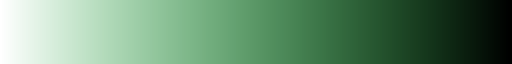

In [105]:
cmap_chi2 = sns.cubehelix_palette(start=2, rot=0, dark=0, light=1, as_cmap=True)
cmap_chi2

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_158387/825884739.py:9: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(j, j+1))
/tmp/ipykernel_158387/825884739.py:11: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_xlabel('$\log_{10} (f_{duty})$')
/tmp/ipykernel_158387/82

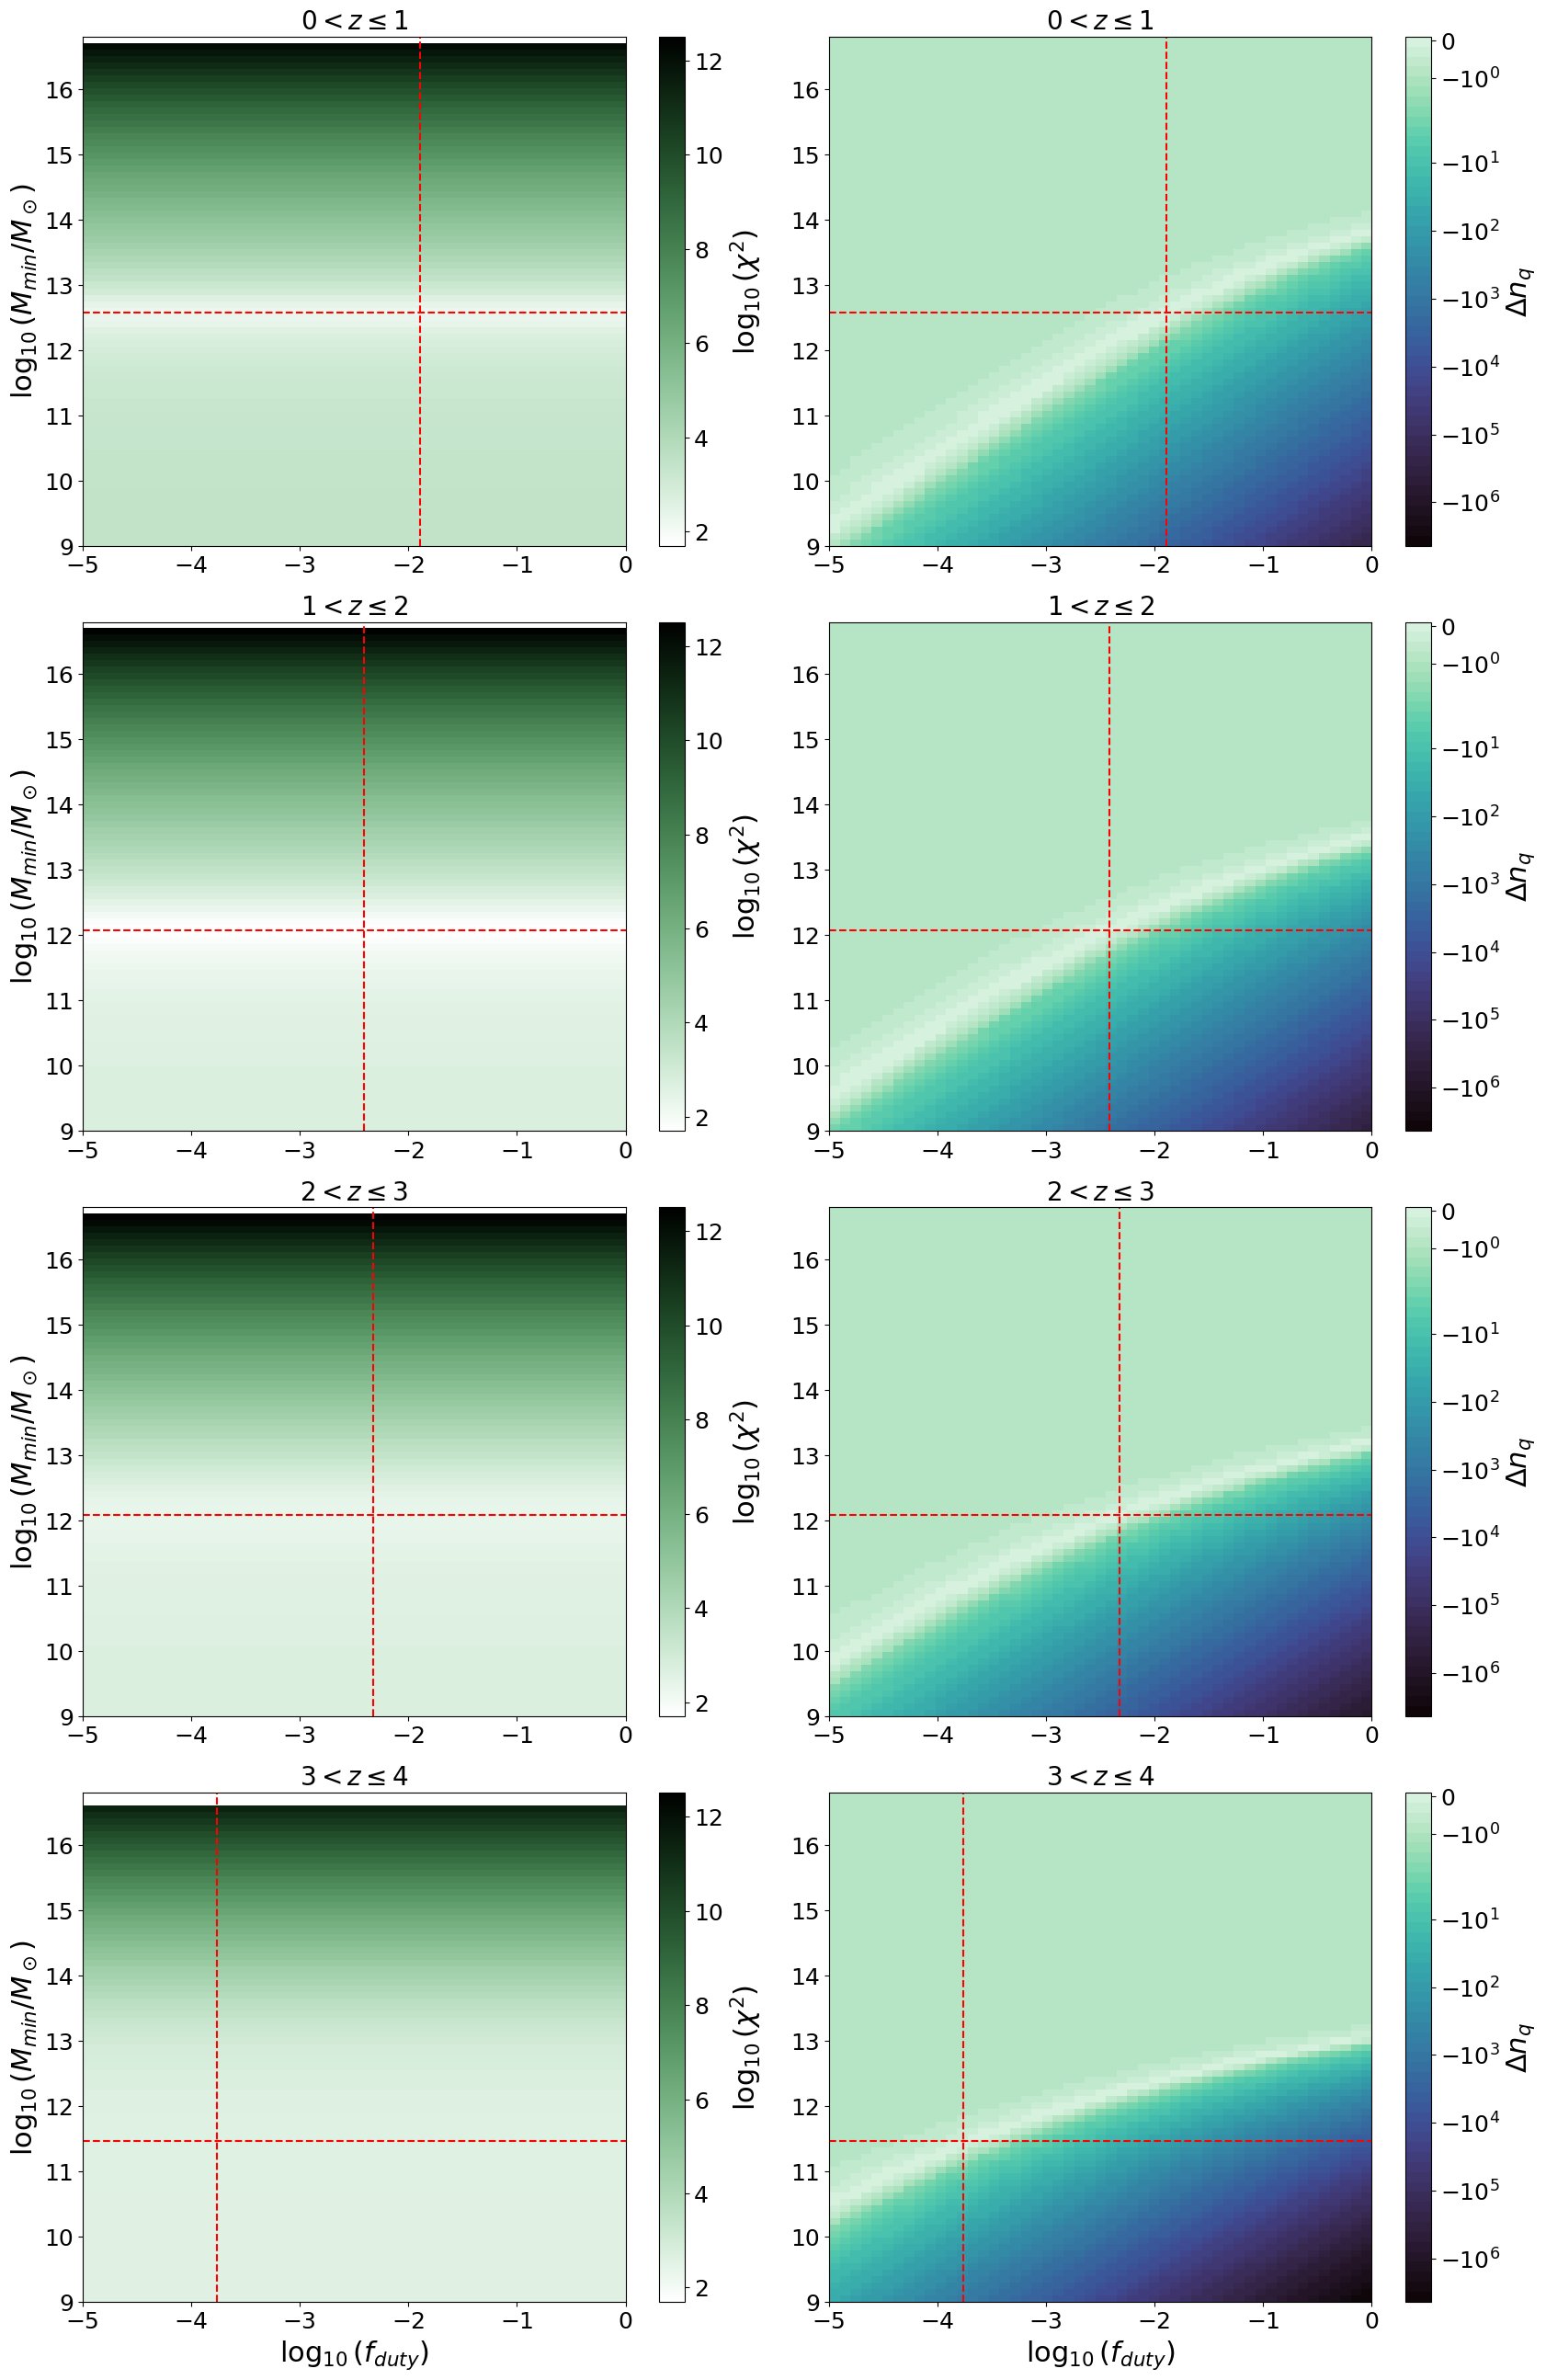

In [106]:
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, hspace = 0.15, wspace = 0.1)

for j in z_array:
    
    ax1 = fig.add_subplot(gs[j*2])
    image = ax1.imshow(np.log10(chi2_grid[j]), cmap = cmap_chi2, vmin = np.log10(50.13706414974333), vmax = np.log10(3216118165719.2197), extent =  [np.log10(fduty_array[0]), np.log10(fduty_array[-1]), np.log10(bins[0]), np.log10(bins[-1])], aspect = 'auto', origin = 'lower')
    # print(image.get_clim())
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(j, j+1))
    if j == 3:
        ax1.set_xlabel('$\log_{10} (f_{duty})$')
    ax1.set_ylabel('$\log_{10} (M_{min}/M_\odot)$')
    fig.colorbar(image, label='$\log_{10} (\chi^2)$')
    ax1.axhline(np.log10(M_min_fit[j]), color = 'red', linestyle = '--')
    ax1.axvline(np.log10(fduty_fit[j]), color = 'red', linestyle = '--')
    
    ax1 = fig.add_subplot(gs[j*2+1])
    image = ax1.imshow(cons_grid[j], cmap = palette_fduty, norm = 'symlog', vmin = -4348491.828200184, vmax = 0.09959201649593023, extent = [np.log10(fduty_array[0]), np.log10(fduty_array[-1]), np.log10(bins[0]), np.log10(bins[-1])], aspect = 'auto', origin = 'lower')
    # print(image.get_clim())
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(j, j+1))
    if j == 3:
        ax1.set_xlabel('$\log_{10} (f_{duty})$')
    # ax1.set_ylabel('$\log_{10} (M_{min})$')
    fig.colorbar(image, label='$\Delta n_q$')
    ax1.axhline(np.log10(M_min_fit[j]), color = 'red', linestyle = '--')
    ax1.axvline(np.log10(fduty_fit[j]), color = 'red', linestyle = '--')

plt.show()

## Plot results

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_158387/686126572.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')


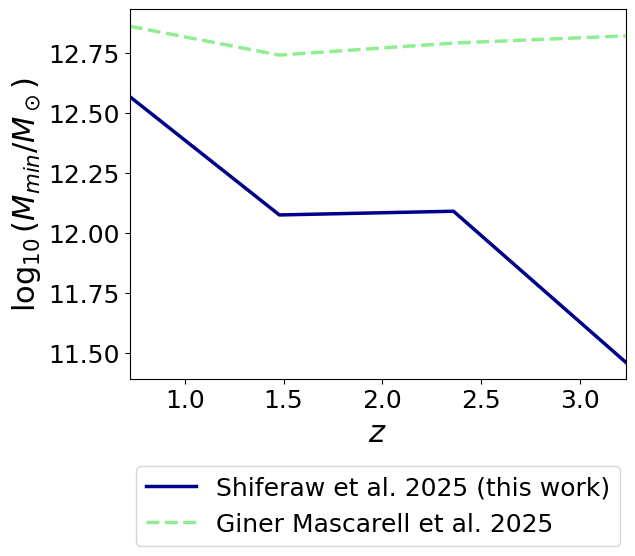

In [107]:
plt.plot(zbin, np.log10(M_min_fit), color = 'darkblue', linewidth = 2.5, label = 'Shiferaw et al. 2025 (this work)')
plt.plot(zbin, M_min_array, label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
# plt.axhline(12.8, label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
# plt.yscale('log')
plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')
plt.xlabel('$z$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(zbin[0], zbin[-1])
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\l'
<>:4: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_158387/2769922354.py:4: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(f_{duty})$')


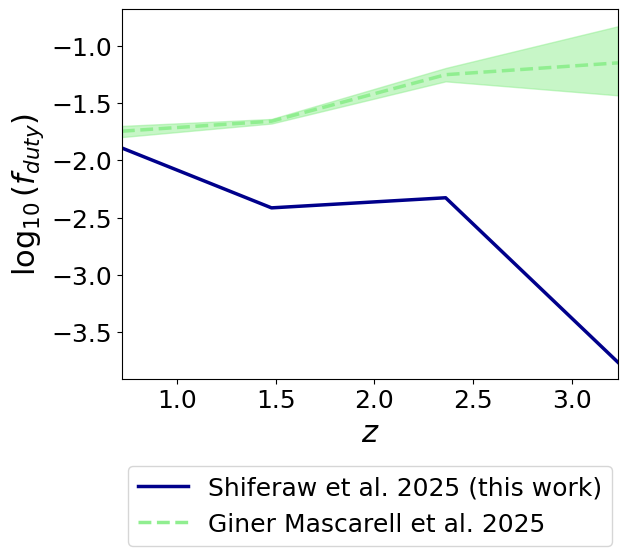

In [108]:
plt.plot(zbin, np.log10(fduty_fit), color = 'darkblue', linewidth = 2.5, label = 'Shiferaw et al. 2025 (this work)')
plt.fill_between(zbin, np.log10(np.array(fduty)+fduty_err_hi), np.log10(np.array(fduty)-fduty_err_lo), alpha = 0.5, color = 'lightgreen')
plt.plot(zbin, np.log10(fduty), label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
plt.ylabel('$\log_{10}(f_{duty})$')
plt.xlabel('$z$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(zbin[0], zbin[-1])
plt.show()

<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_158387/3548159967.py:42: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))


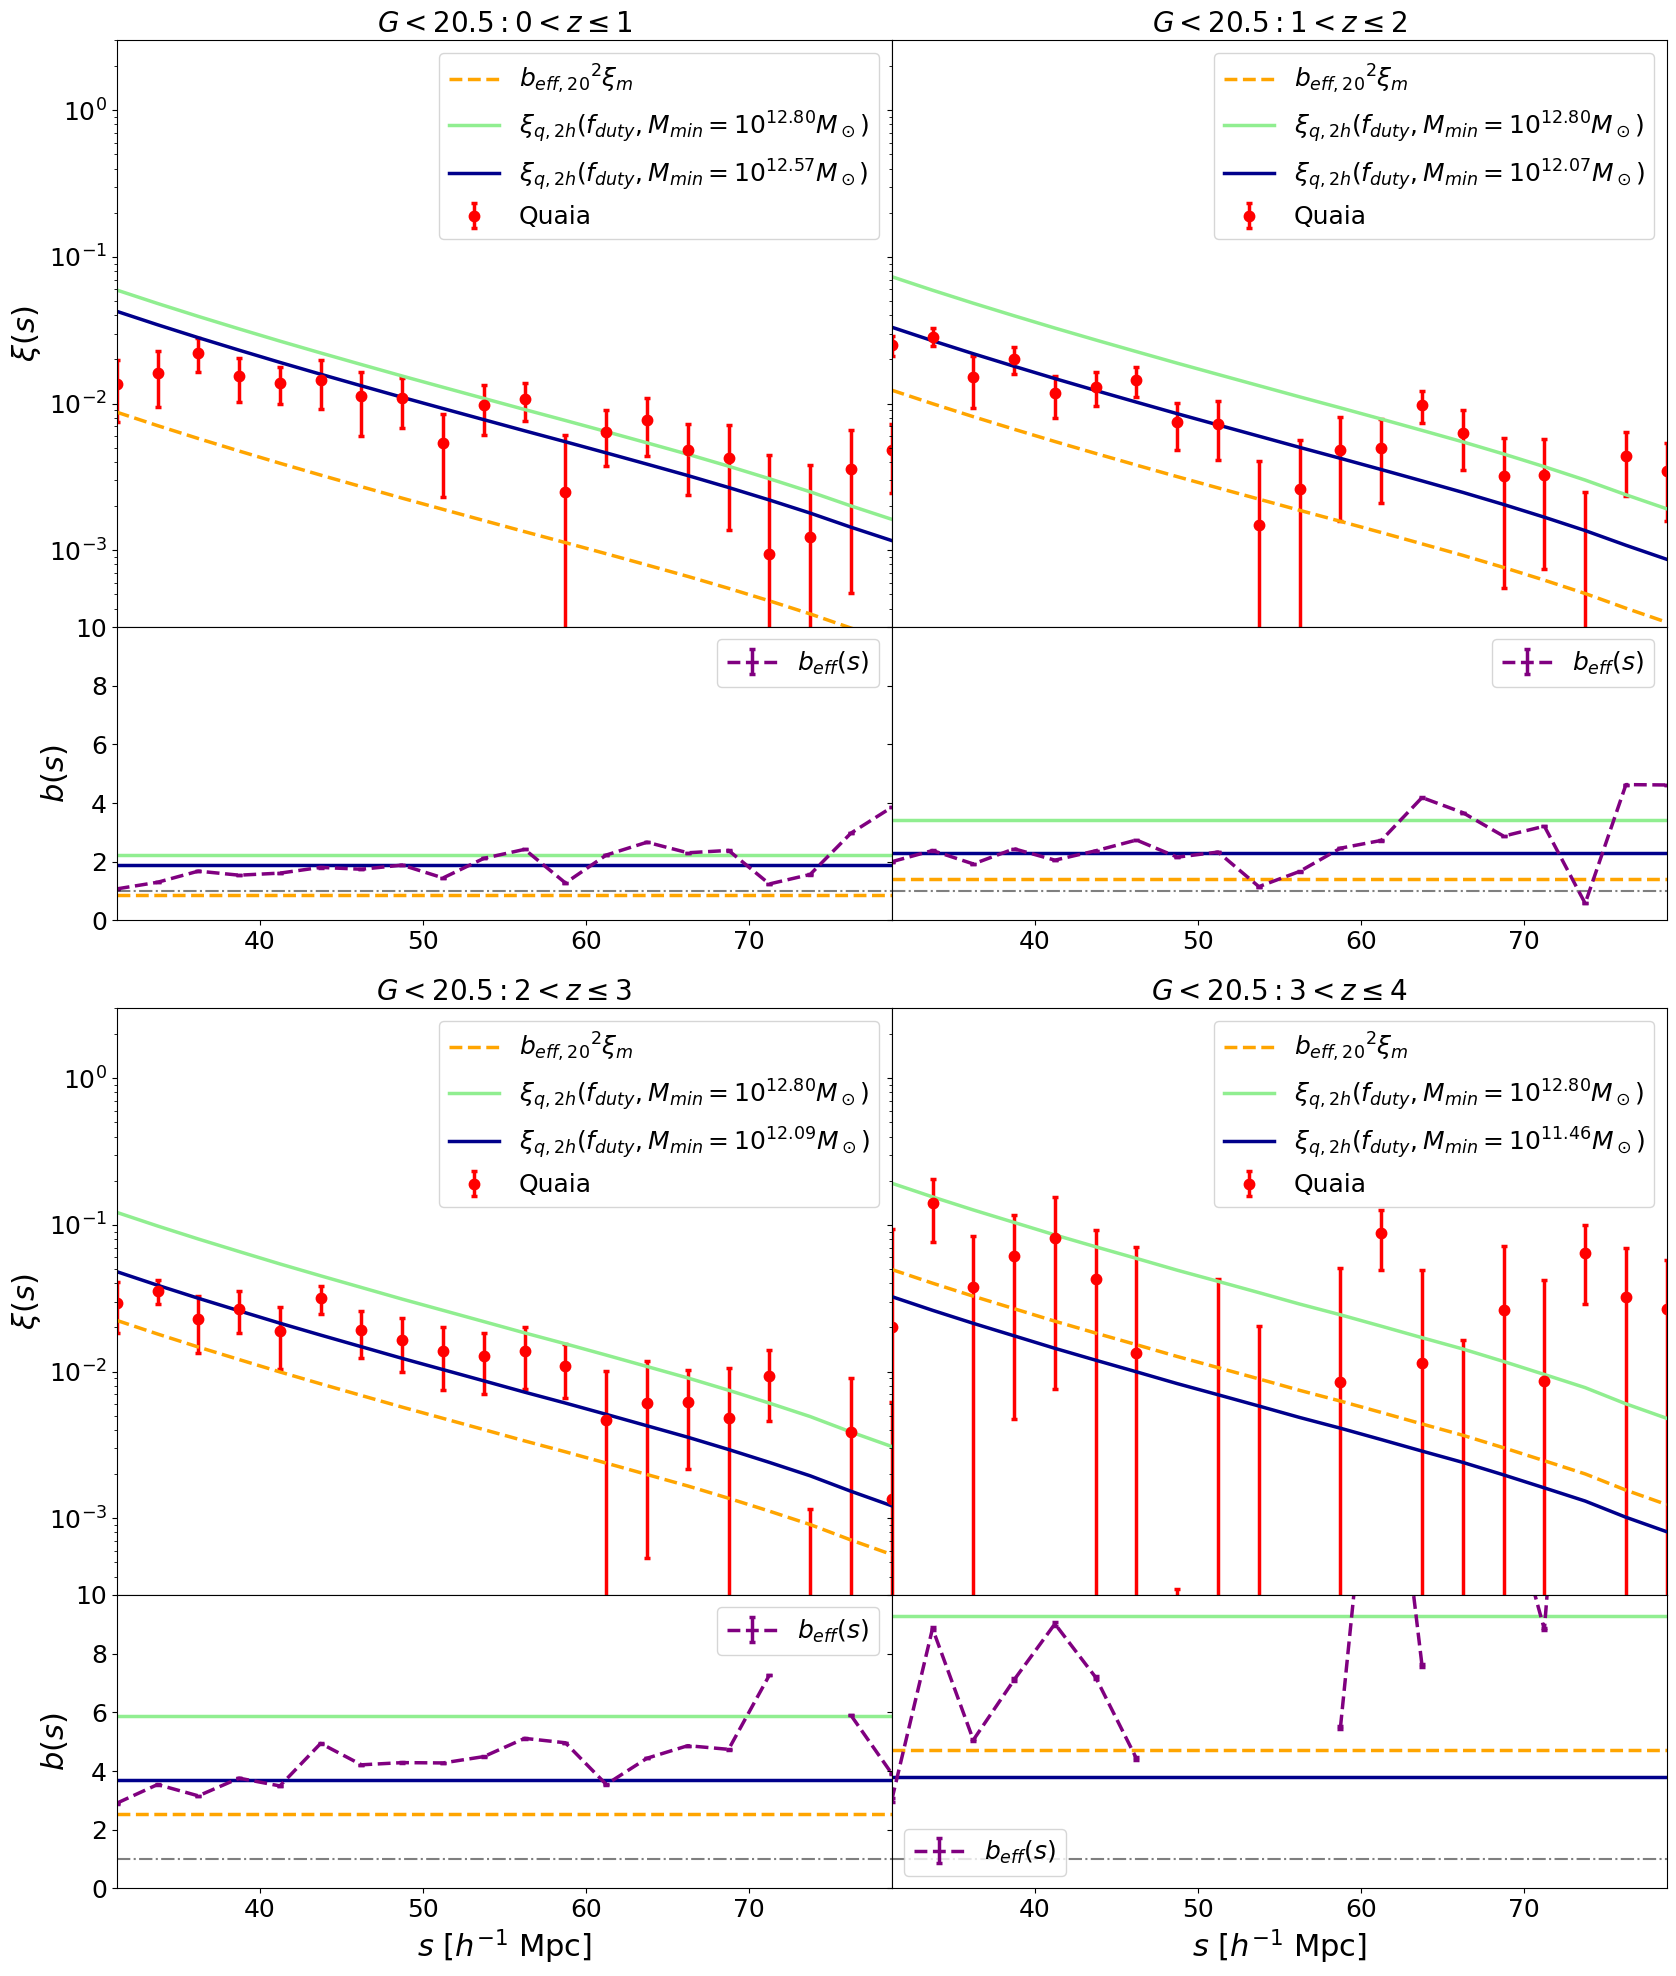

In [109]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.15, 1, 0.5], hspace = 0, wspace = 0)

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))
            
    ax1.errorbar(quaia.recenter(rbins_chi2), cf_chi2[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red',
                yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    # ax1.errorbar(quaia.recenter(rbins_chi2), cf_chi2_b[j], linewidth = 2.5, marker = 'o', label = r'Quaia, $|b|\geq 30^\circ$', color = 'pink',
    #             yerr = yerr_cf_chi2_b[j], markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.plot(quaia.recenter(rbins_chi2), b_eff_cf20[j]**2*cf_matter_chi2[labels[i]][j], linewidth = 2.5,
             label = r'${b_{eff, 20}}^2\xi_m$', color = 'orange', linestyle = '--')

    # old fit
    cf_2h_zbin, b_q = cf_2h(bins_M_min[j], n_m_array[j], a_zbin[labels[i]][j], cosmos[i], cf_matter_chi2[labels[i]][j], recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5, label = r'$\xi_{q,2h}(f_{duty}, M_{min}=10^{12.80}M_\odot)$',
             color = 'lightgreen')
    ax2.axhline(b_q, linewidth = 2.5, color = 'lightgreen')

    # plot new fit
    n_m=np.ones(np.shape(bins))*fduty[j]
    cf_2h_zbin, b_q = cf_2h(np.logspace(np.log10(M_min_fit[j]),16.8,79), n_m, a_zbin[labels[i]][j], cosmos[i], cf_matter_chi2[labels[i]][j], 
                            recenter = False)
    # cf_2h_zbin, b_q = cf_2h(np.logspace(np.log10(M_min_fit[j]),16.8,79), n_m, a_zbin_b[j], cosmos[i], cf_matter_chi2_b[j], 
    #                         recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5,
             label = r'$\xi_{{q,2h}}(f_{{duty}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(M_min_fit[j])), color = 'darkblue')
    ax2.axhline(b_q, linewidth = 2.5, color = 'darkblue')

    ax2.errorbar(quaia.recenter(rbins_chi2), b_cf_chi2[labels[i]][j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5,
                 color = 'purple', yerr = np.sqrt(np.diag(C)), label = '$b_{eff}(s)$')
    # ax2.errorbar(quaia.recenter(rbins_chi2), b_cf_chi2_b[j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5,
    #              color = 'brown', yerr = yerr_cf_chi2_b[j], label = '$b_{eff}(s), |b|\geq 30^\circ$')
    ax2.axhline(b_eff_cf20[j], linewidth = 2.5, color = 'orange', linestyle = '--')

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 3)
    ax1.legend()

    ax2.axhline(1, linestyle = '-.', color = 'black', alpha = 0.5)
    ax2.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax2.set_ylim(0, 10)
    ax2.legend()
    
    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    # else:
    #     ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_158387/3368088303.py:47: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))


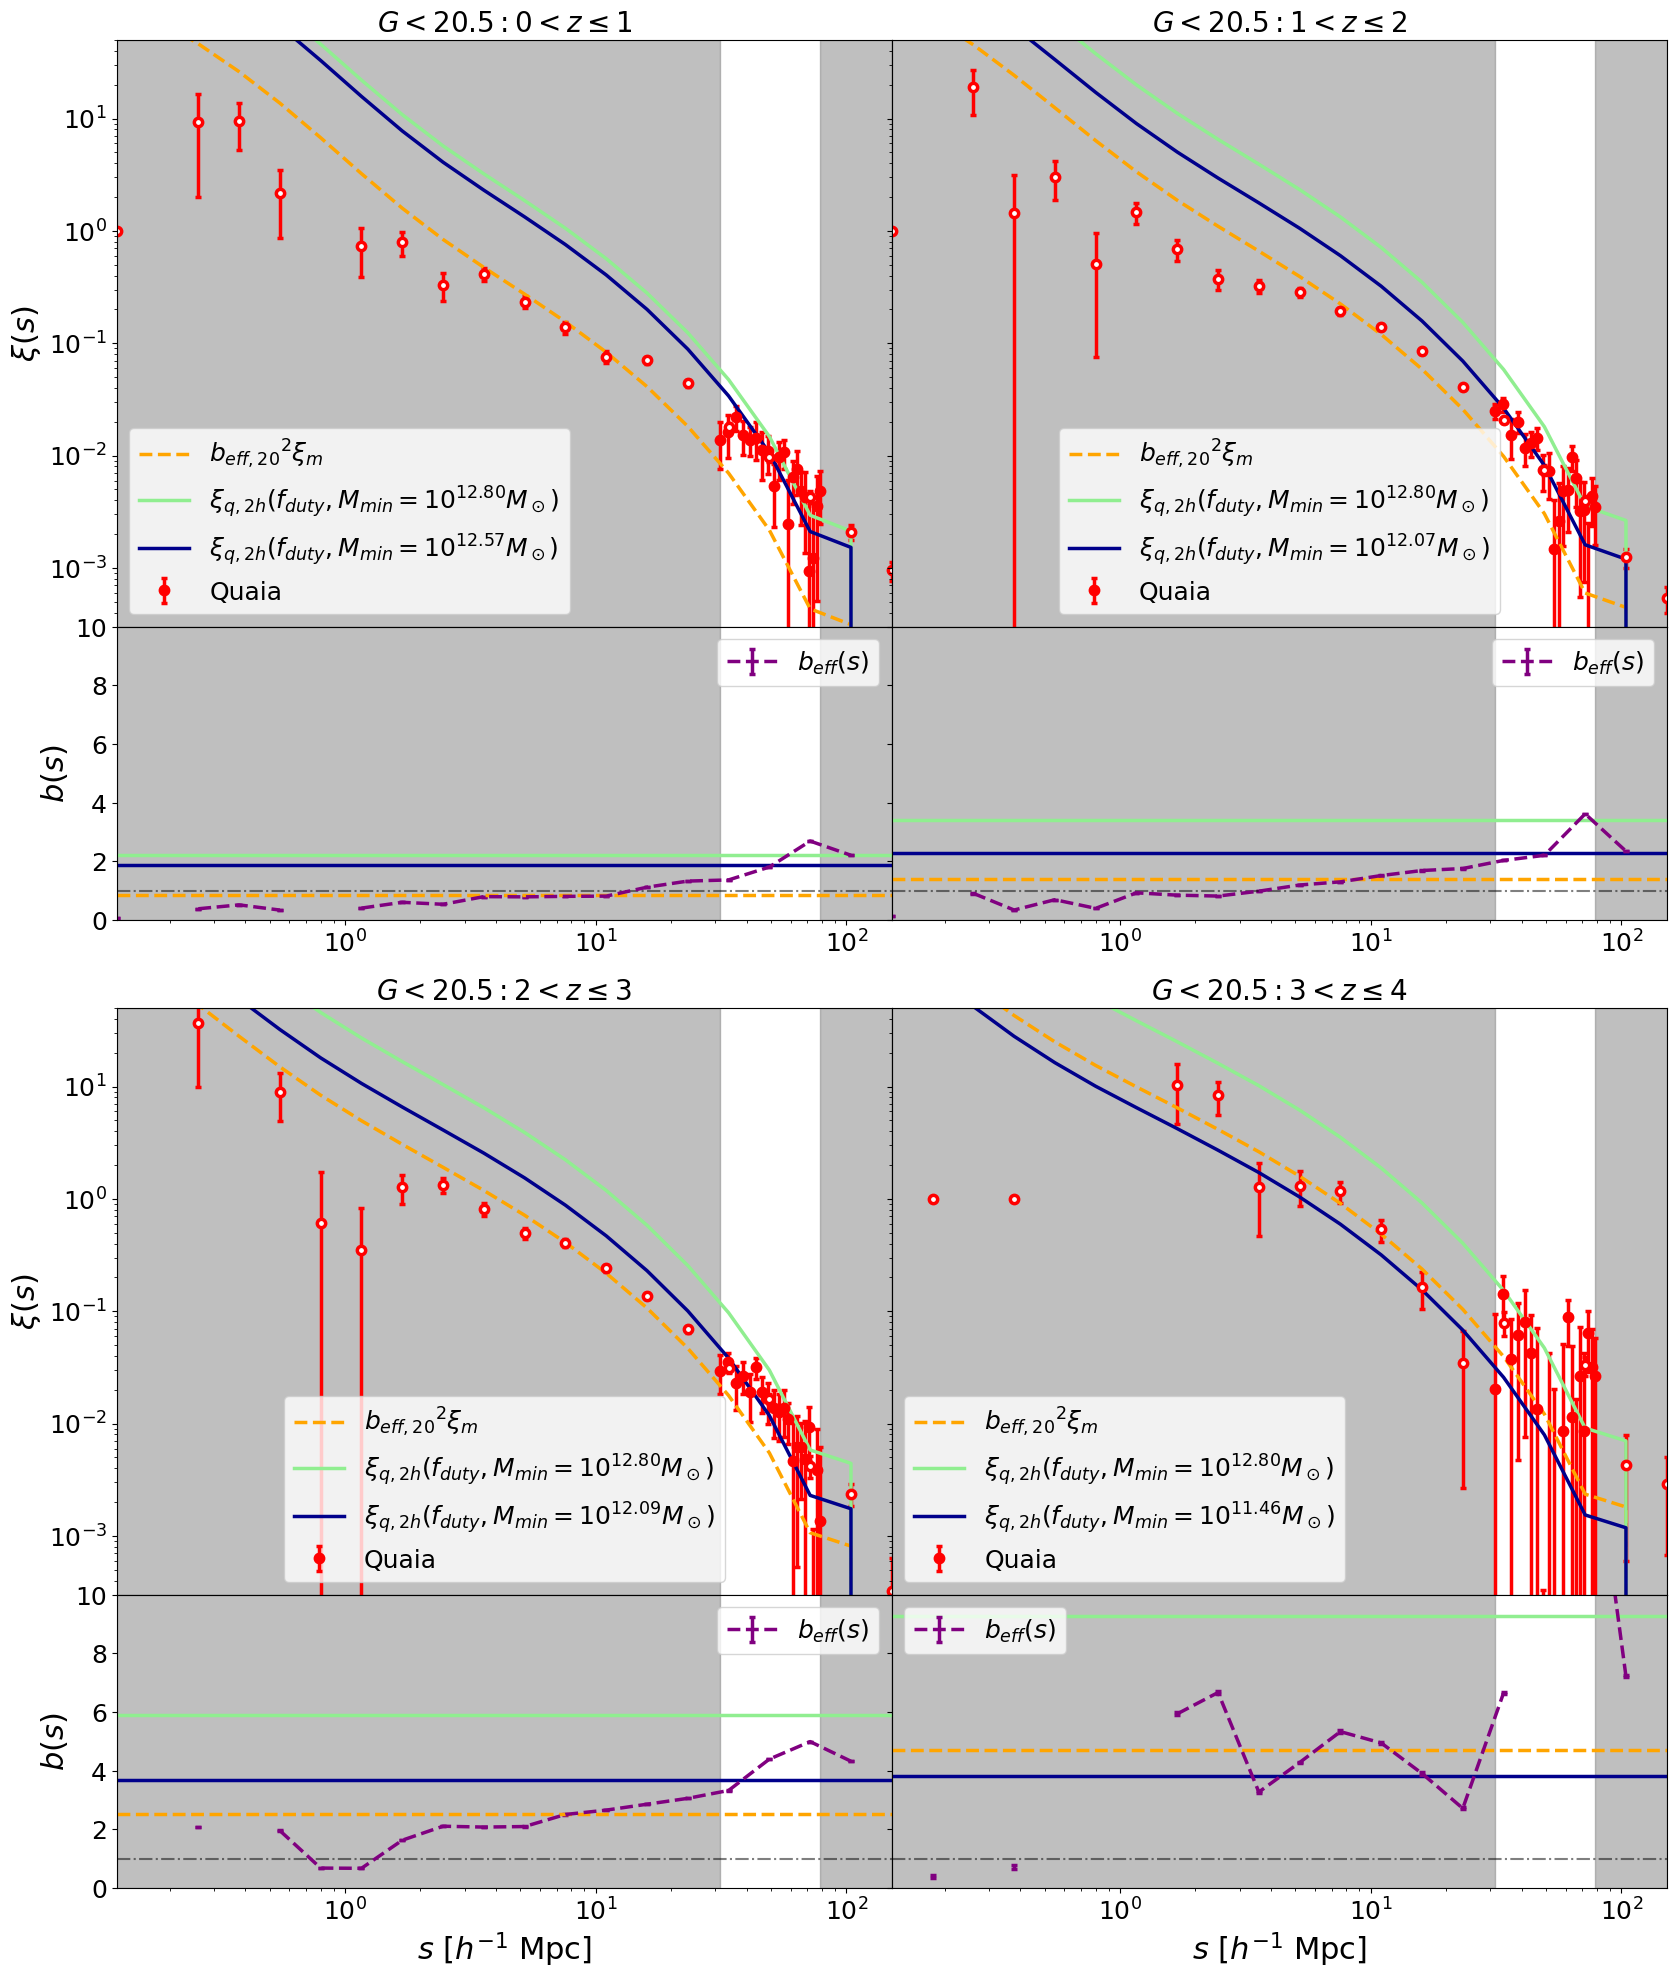

In [110]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.15, 1, 0.5], hspace = 0, wspace = 0)

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))
            
    ax1.errorbar(quaia.recenter(rbins_chi2), cf_chi2[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red',
                yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    # ax1.errorbar(quaia.recenter(rbins_chi2), cf_chi2_b[j], linewidth = 2.5, marker = 'o', label = r'Quaia, $|b|\geq 30^\circ$', color = 'pink',
    #             yerr = yerr_cf_chi2_b[j], markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', color = 'red', markerfacecolor = 'white',
                yerr = yerr_cf[labels[i]][j], markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.plot(quaia.recenter(rbins), b_eff_cf20[j]**2*cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5,
             label = r'${b_{eff, 20}}^2\xi_m$', color = 'orange', linestyle = '--')
    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins)[0], x2 = quaia.recenter(rbins_chi2)[0], color = 'grey', alpha = 0.5)
    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[-1], x2 = quaia.recenter(rbins)[-1], color = 'grey', alpha = 0.5)

    # old fit, all scales
    cf_2h_zbin, b_q = cf_2h(bins_M_min[j], n_m_array[j], a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j], recenter = False)
    ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, color = 'lightgreen', label = r'$\xi_{q,2h}(f_{duty}, M_{min}=10^{12.80}M_\odot)$')
    ax2.axhline(b_q, linewidth = 2.5, color = 'lightgreen')

    # plot new fit
    n_m=np.ones(np.shape(bins))*fduty[j]
    cf_2h_zbin, b_q = cf_2h(np.logspace(np.log10(M_min_fit[j]), 16.8, 79), n_m, a_zbin[labels[i]][j], cosmos[i], 
                            cf_matter_zbin_percentile[labels[i]][j], recenter = False)
    # cf_2h_zbin, b_q = cf_2h(np.logspace(np.log10(M_min_fit[j]), 16.8, 79), n_m, a_zbin_b[j], cosmos[i], 
    #                         cf_matter_zbin_percentile[labels[i]][j], recenter = False)
    ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, label = r'$\xi_{{q,2h}}(f_{{duty}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(M_min_fit[j])),
             color = 'darkblue')
    ax2.axhline(b_q, linewidth = 2.5, color = 'darkblue')

    ax2.errorbar(quaia.recenter(rbins), b_cf[labels[i]][j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5,
                 color = 'purple', yerr = np.sqrt(np.diag(C)), label = '$b_{eff}(s)$')
    # ax2.errorbar(quaia.recenter(rbins_chi2), b_cf_chi2_b[j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5,
    #              color = 'brown', yerr = yerr_cf_chi2_b[j], label = '$b_{eff}(s), |b|\geq 30^\circ$')
    ax2.axhline(b_eff_cf20[j], linewidth = 2.5, color = 'orange', linestyle = '--')
    ax2.fill_betweenx(np.linspace(0, 10), x1 = quaia.recenter(rbins)[0], x2 = quaia.recenter(rbins_chi2)[0], color = 'grey', alpha = 0.5)
    ax2.fill_betweenx(np.linspace(0, 10), x1 = quaia.recenter(rbins_chi2)[-1], x2 = quaia.recenter(rbins)[-1], color = 'grey', alpha = 0.5)

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)
    ax1.legend()

    ax2.axhline(1, linestyle = '-.', color = 'black', alpha = 0.5)
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 10)
    ax2.legend()
    
    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    # if scale == 'log':
    ax1.set_xscale('log')
    ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    # else:
    #     ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

<>:46: SyntaxWarning: invalid escape sequence '\c'
<>:51: SyntaxWarning: invalid escape sequence '\o'
<>:46: SyntaxWarning: invalid escape sequence '\c'
<>:51: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_158387/4098080813.py:46: SyntaxWarning: invalid escape sequence '\c'
  '$\chi^2$ minimization', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)',
/tmp/ipykernel_158387/4098080813.py:51: SyntaxWarning: invalid escape sequence '\o'
  cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


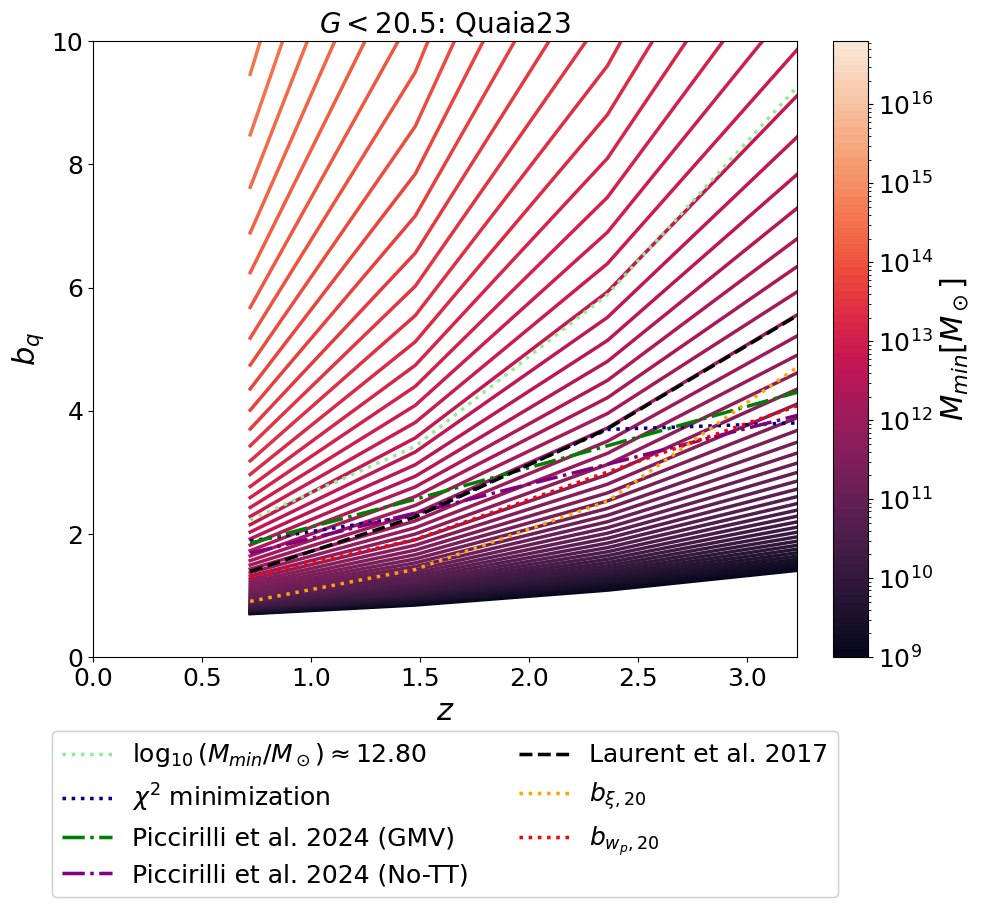

In [111]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])

for k in range(len(bins)):
    
    b_q = [cf_2h(bins_M_min_array[k], n_m_array_2D[j][k], a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j], 
                 recenter = False)[1] for j in z_array]
    zbin = 1/np.array(a_zbin[labels[i]])-1
    ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap[k]) #grey,
    
b_q = [cf_2h(bins_M_min[j], n_m_array[j], a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j], 
             recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

b_q = [cf_2h(np.logspace(np.log10(M_min_fit[j]), 16.8, 79), np.ones(np.shape(bins))*fduty[j], a_zbin[labels[i]][j], cosmos[i], 
             cf_matter_zbin_percentile[labels[i]][j], recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.plot(zbin, b_quaia(1.26, a_zbin[labels[i]]), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_quaia(1.15, a_zbin[labels[i]]), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
         color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761

ax1.plot(zbin, b_cf20, linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
ax1.plot(zbin, b_wp20, linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

ax1.set_xlabel('$z$')
ax1.set_ylim(0, 10)
ax1.set_xlim(0, zbin[-1])
ax1.set_ylabel(r'$b_q$')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min), 
                                          '$\chi^2$ minimization', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 
                                          'Laurent et al. 2017', r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 2, bbox_to_anchor = (0.5, -0.1), 
                           loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

<>:46: SyntaxWarning: invalid escape sequence '\c'
<>:46: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_158387/285168766.py:46: SyntaxWarning: invalid escape sequence '\c'
  '$\chi^2$ minimization', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)',


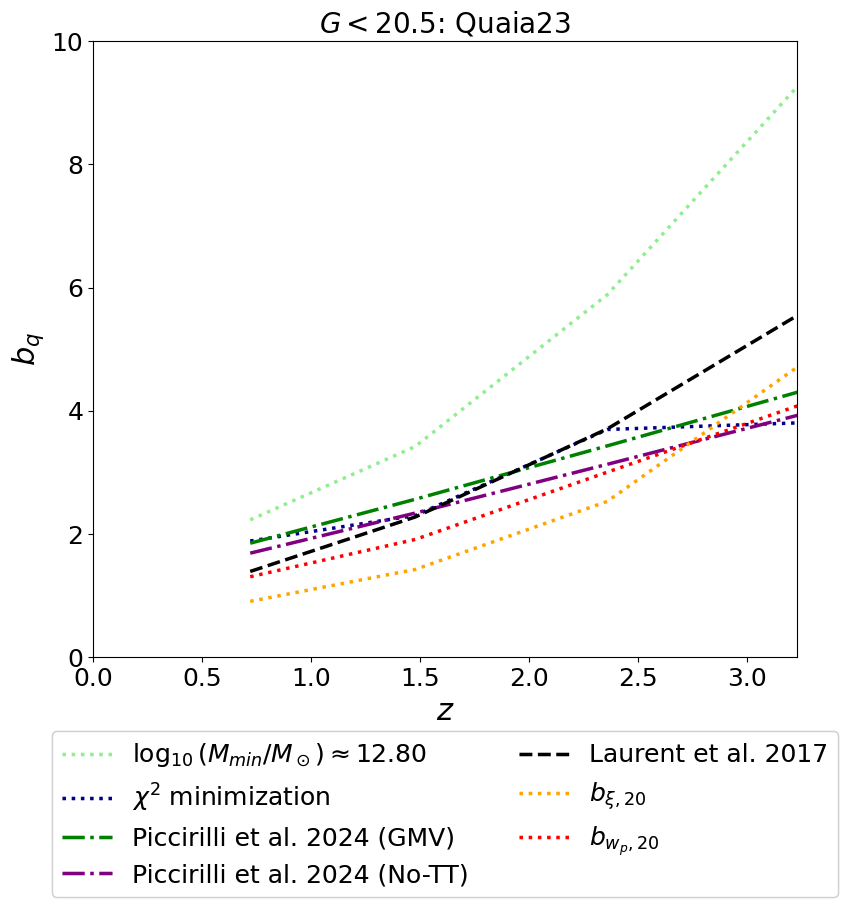

In [112]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])

# for k in range(len(bins)):
    
#     b_q = [cf_2h(bins_M_min_array[k], n_m_array_2D[j][k], a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j], 
#                  recenter = False)[1] for j in z_array]
#     zbin = 1/np.array(a_zbin[labels[i]])-1
#     ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap[k]) #grey,
    
b_q = [cf_2h(bins_M_min[j], n_m_array[j], a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j], 
             recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

b_q = [cf_2h(np.logspace(np.log10(M_min_fit[j]), 16.8, 79), np.ones(np.shape(bins))*fduty[j], a_zbin[labels[i]][j], cosmos[i], 
             cf_matter_zbin_percentile[labels[i]][j], recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.plot(zbin, b_quaia(1.26, a_zbin[labels[i]]), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_quaia(1.15, a_zbin[labels[i]]), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
         color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761

ax1.plot(zbin, b_cf20, linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
ax1.plot(zbin, b_wp20, linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

ax1.set_xlabel('$z$')
ax1.set_ylim(0, 10)
ax1.set_xlim(0, zbin[-1])
ax1.set_ylabel(r'$b_q$')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min), 
                                          '$\chi^2$ minimization', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 
                                          'Laurent et al. 2017', r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 2, bbox_to_anchor = (0.5, -0.1), 
                           loc='upper center')
fig.add_artist(second_legend)

# cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

In [113]:
for k in range(len(bins)):
    M_vary = np.log10(M_min_fit[j])-1+k/int(len(bins)/2)
    if M_vary == np.log10(M_min_fit[j]):
        print(M_vary,'*')
    else:
        print(M_vary)

10.459925367605644
10.48556639324667
10.511207418887695
10.53684844452872
10.562489470169746
10.588130495810772
10.613771521451797
10.639412547092823
10.665053572733848
10.690694598374874
10.716335624015901
10.741976649656927
10.767617675297952
10.793258700938978
10.818899726580003
10.844540752221029
10.870181777862054
10.89582280350308
10.921463829144106
10.947104854785131
10.972745880426157
10.998386906067182
11.024027931708208
11.049668957349233
11.075309982990259
11.100951008631284
11.12659203427231
11.152233059913335
11.177874085554361
11.203515111195387
11.229156136836414
11.25479716247744
11.280438188118465
11.30607921375949
11.331720239400516
11.357361265041542
11.383002290682567
11.408643316323593
11.434284341964618
11.459925367605644 *
11.48556639324667
11.511207418887695
11.53684844452872
11.562489470169746
11.588130495810772
11.613771521451797
11.639412547092823
11.665053572733848
11.690694598374876
11.716335624015901
11.741976649656927
11.767617675297952
11.793258700938978

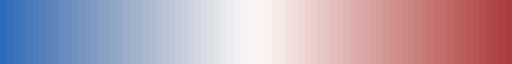

In [114]:
cmap_M_min = sns.color_palette("vlag", n_colors = len(bins))
palette_M_min = matplotlib.colors.ListedColormap(cmap_M_min)
palette_M_min

<>:57: SyntaxWarning: invalid escape sequence '\c'
<>:63: SyntaxWarning: invalid escape sequence '\D'
<>:57: SyntaxWarning: invalid escape sequence '\c'
<>:63: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_158387/2150857633.py:57: SyntaxWarning: invalid escape sequence '\c'
  '$\chi^2$ minimization', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)',
/tmp/ipykernel_158387/2150857633.py:63: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


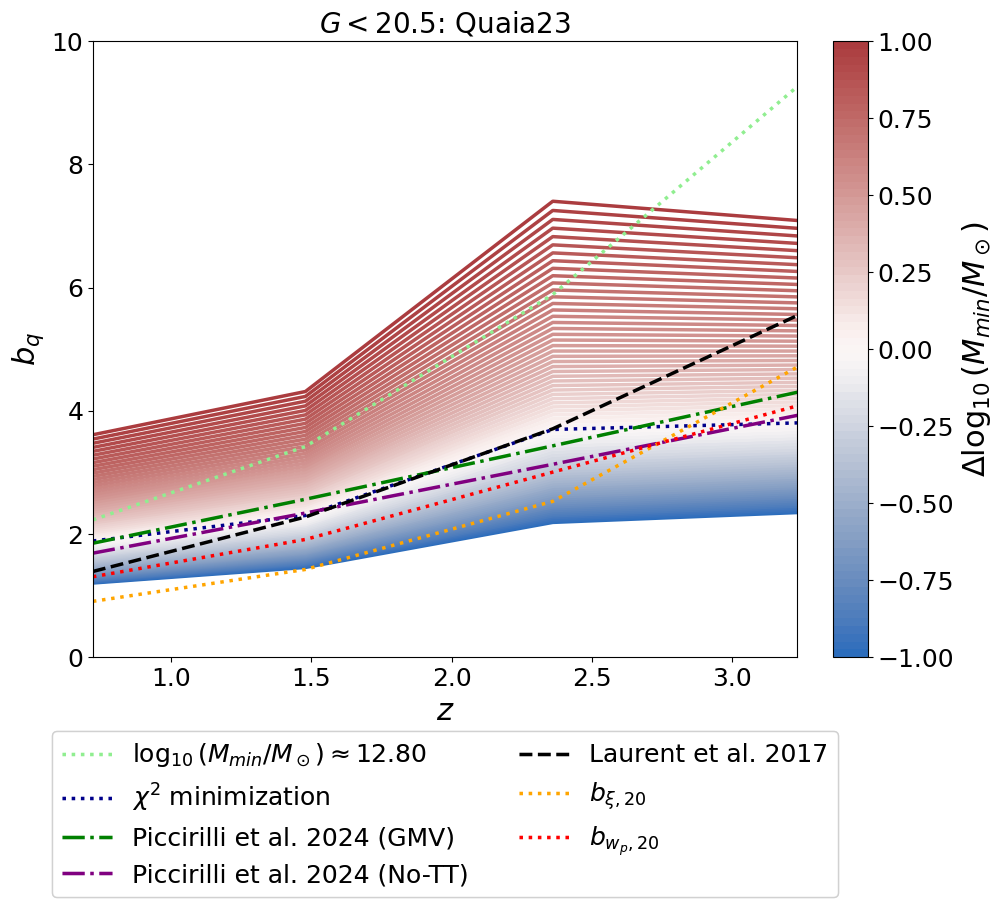

In [115]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])

zbin = 1/np.array(a_zbin[labels[i]])-1
# for k in range(len(bins)):
    
#     b_q = [cf_2h(bins_M_min_array[k], n_m_array_2D[j][k], a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j], 
#                  recenter = False)[1] for j in z_array]
#     # zbin = 1/np.array(a_zbin[labels[i]])-1
#     ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap[k]) #grey,
    
b_q = [cf_2h(bins_M_min[j], n_m_array[j], a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j], 
             recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

b_q = [cf_2h(np.logspace(np.log10(M_min_fit[j]), 16.8, 79), np.ones(np.shape(bins))*fduty[j], a_zbin[labels[i]][j], cosmos[i], 
             cf_matter_zbin_percentile[labels[i]][j], recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

for k in range(len(bins)):
    b_q = [cf_2h(np.logspace(np.log10(M_min_fit[j])-1+k/int(len(bins)/2), 16.8, 79), np.ones(np.shape(bins))*fduty[j], a_zbin[labels[i]][j], 
                 cosmos[i], cf_matter_zbin_percentile[labels[i]][j], recenter = False)[1] for j in z_array]
    # b_q=[]
    # for j in z_array:
    #     M_mins = np.log10(np.logspace(np.log10(M_min_fit[j])-1, np.log10(M_min_fit[j])+1, 79))
    #     b_q.append(cf_2h(np.logspace(M_mins[k], 16.8, 79), np.ones(np.shape(bins))*fduty[j], a_zbin[labels[i]][j], 
    #                  cosmos[i], cf_matter_zbin_percentile[labels[i]][j], recenter = False)[1])
    ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.plot(zbin, b_quaia(1.26, a_zbin[labels[i]]), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_quaia(1.15, a_zbin[labels[i]]), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
         color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761

ax1.plot(zbin, b_cf20, linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
ax1.plot(zbin, b_wp20, linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

ax1.set_xlabel('$z$')
ax1.set_ylim(0, 10)
ax1.set_xlim(zbin[0], zbin[-1])
ax1.set_ylabel(r'$b_q$')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min), 
                                          '$\chi^2$ minimization', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 
                                          'Laurent et al. 2017', r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 2, bbox_to_anchor = (0.5, -0.1), 
                           loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

<>:35: SyntaxWarning: invalid escape sequence '\c'
<>:45: SyntaxWarning: invalid escape sequence '\o'
<>:35: SyntaxWarning: invalid escape sequence '\c'
<>:45: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_158387/3082048959.py:35: SyntaxWarning: invalid escape sequence '\c'
  second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min), '$\chi^2$ minimization',
/tmp/ipykernel_158387/3082048959.py:45: SyntaxWarning: invalid escape sequence '\o'
  cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


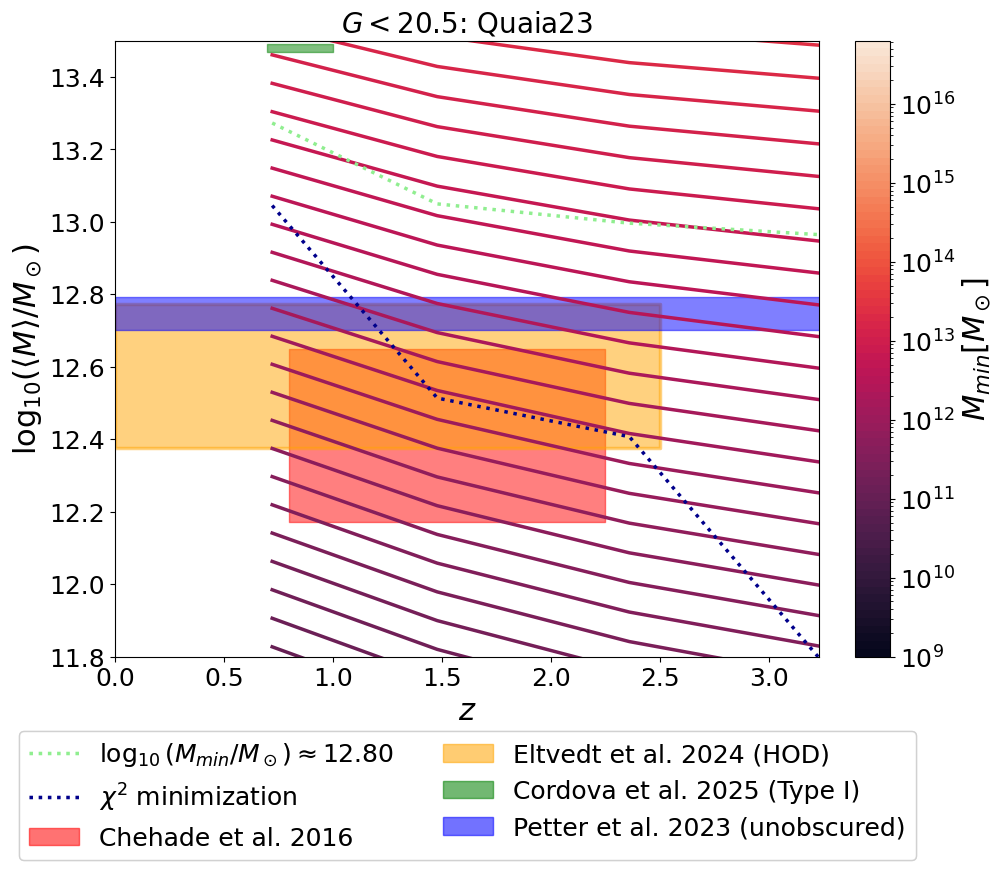

In [116]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
i = 1

for k in range(len(bins)):
    
    M_h = [M(bins_M_min_array[k], n_m_array_2D[j][k], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[0] for j in z_array]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, 
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
             color = cmap[k]) #, alpha = (1+k)/len(bins))
    
M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

M_h = [M(np.logspace(np.log10(M_min_fit[j]), 16.8, 79), np.ones(np.shape(bins))*fduty[j], a = a_zbin[labels[i]][j], cosmo = cosmos[i], 
         recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

z = np.linspace(0.8, 2.25)
ax1.fill_between(z, [np.log10(1e12/cosmo_quaia['h'])]*len(z), [np.log10(3e12/cosmo_quaia['h'])]*len(z), alpha = 0.5, label = 'Chehade et al. 2016', 
                 color = 'red')
ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/cosmo_quaia['h'])]*len(z), [np.log10(4e12/cosmo_quaia['h'])]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/cosmo_quaia['h'])]*len(z), [np.log10(10**12.62/cosmo_quaia['h'])]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min), '$\chi^2$ minimization',
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(0, zbin[-1])
ax1.set_ylim(11.8, 13.5)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

<>:33: SyntaxWarning: invalid escape sequence '\c'
<>:43: SyntaxWarning: invalid escape sequence '\o'
<>:33: SyntaxWarning: invalid escape sequence '\c'
<>:43: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_158387/2050277147.py:33: SyntaxWarning: invalid escape sequence '\c'
  label = '$\chi^2$ minimization'),
/tmp/ipykernel_158387/2050277147.py:43: SyntaxWarning: invalid escape sequence '\o'
  cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_158387/1331995612.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_158387/2050277147.py:10: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(zbin, np.log10(n_q_

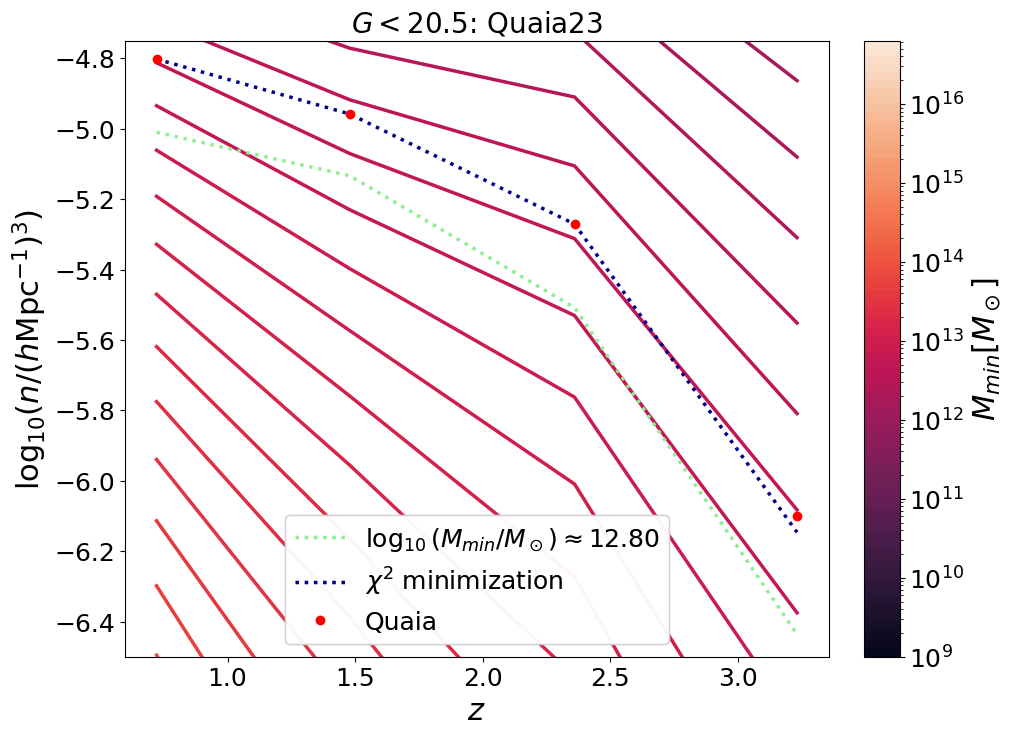

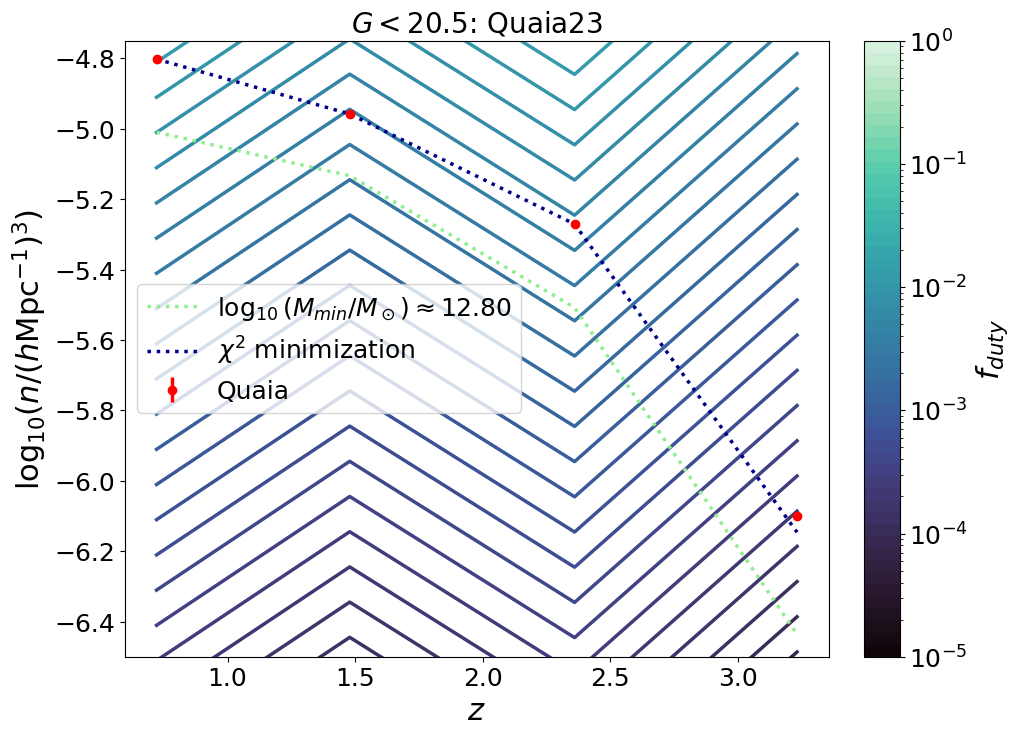

In [117]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
ylim = -6.5, -4.75

for k in range(len(bins)):
    
    n_q_theory = [M(bins_M_min_array[k], n_m_array_2D[j][k], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1] for j in z_array]
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:[{:.2f}-{:.2f}] M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[0]), 
                                                                                                  np.log10(bins[-1])), color = cmap[k])

n_q_theory, n_q_theory_fit = [], []
for j in z_array:
    
    n_q_theory.append(M(bins_M_min[j], n_m_array[j], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1])
    
    n_m=np.ones(np.shape(bins))*fduty_fit[j]
    # n_m[quaia.recenter(bins)>=M_min_fit[j]]=fduty_fit[j]
    n_q_theory_fit.append(M(np.logspace(np.log10(M_min_fit[j]), 16.8, 79), n_m, a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1])

ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.plot(zbin, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'$\chi^2$ minimization') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5, 
                       label = r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min)),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5, 
                       label = '$\chi^2$ minimization'), 
                Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia')]
second_legend = ax1.legend(handles = custom_lines)
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
# plt.legend()
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
i = 1
l = 38

for k in range(len(fduty_array)):

    n_q_theory=[]
    for j in z_array:
        
        n_m=np.ones(np.shape(bins))*fduty_array[k]
        # n_m[quaia.recenter(bins)>=M_min_fit[j]]=fduty_array[k]
        n_q_theory.append(M(np.logspace(np.log10(M_min_fit[j]), 16.8, 79), n_m, a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1])
        
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             color = cmap_fduty[k])
    
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[labels[i]][j], cosmo = cosmos[i], recenter = False)[1] for j in z_array]
ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':', 
         label = r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(np.log10(bins[l]))) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.plot(zbin, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'$\chi^2$ minimization') # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)
ax1.legend()

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_fduty, norm = matplotlib.colors.LogNorm(vmin=fduty_array[0], vmax = fduty_array[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$f_{duty}$')
plt.show()